# Lectura de datos y definición de periodos

In [ ]:
import pandas as pd
import requests
import zipfile
import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math


In [ ]:
# 1. Definir columnas clave para no saturar la RAM de Colab
COLUMNAS_CLAVE = [
    'CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'ANO4', 'TRIMESTRE',
    'ESTADO', 'CAT_OCUP', 'PP07H', # Filtros y Target
    'CH04', 'CH06', 'NIVEL_ED', 'REGION', 'PP04A', 'PP04B_COD', 'PP03D', 'P47T', 'CH07', 'PP04G' # Nodos del grafo
]

def obtener_eph_indec(anio, trimestre):
    """Descarga y extrae la base individual de la EPH directamente del INDEC."""
    # URL estándar del repositorio histórico del INDEC
    url = f"https://www.indec.gob.ar/ftp/cuadros/menusuperior/eph/EPH_usu_{trimestre}_Trim_{anio}_txt.zip"
    print(f"📥 Descargando EPH: Año {anio} - Trimestre {trimestre}...")

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))

        # Buscar el archivo de individuos (ignorando el de hogares)
        archivo_indiv = [f for f in z.namelist() if 'individual' in f.lower()][0]

        with z.open(archivo_indiv) as f:
            # INDEC suele usar punto y coma como separador en sus .txt
            df = pd.read_csv(f, sep=';', usecols=lambda c: c in COLUMNAS_CLAVE, low_memory=False)
        return df
    except Exception as e:
        print(f"❌ Error al descargar {anio}-T{trimestre}: {e}")
        return None

def procesar_informalidad(df, etiqueta_periodo):
    """Aplica los filtros sociológicos y crea la variable Target."""
    if df is None or df.empty:
        return None

    # 1. Filtro: Ocupados (ESTADO == 1) y Asalariados (CAT_OCUP == 3)
    df_filtro = df[(df['ESTADO'] == 1) & (df['CAT_OCUP'] == 3)].copy()

    # 2. Creación del Target: Informalidad
    # PP07H == 2 significa "No le descuentan para la jubilación"
    df_filtro['Informal'] = df_filtro['PP07H'].apply(lambda x: 1 if x == 2 else 0)

    # 3. Limpieza de datos faltantes estructurales del INDEC
    # El valor -9 representa "No responde / No sabe" en ingresos
    df_filtro['P47T'] = df_filtro['P47T'].replace(-9, pd.NA)

    # 4. Etiquetar el período para el análisis comparativo posterior
    df_filtro['Periodo_Hito'] = etiqueta_periodo

    informalidad_media = df_filtro['Informal'].mean()
    print(f"✅ {etiqueta_periodo}: {len(df_filtro)} asalariados procesados. Tasa de Informalidad: {informalidad_media:.2%}")

    return df_filtro

# ==========================================
# EJECUCIÓN PARA TUS 3 PERÍODOS DE TESIS
# ==========================================

# Periodo 1: Auge Plataformas (Usamos 4to Trimestre 2019)
df_2019_t4 = obtener_eph_indec(2019, 4)
df_p1 = procesar_informalidad(df_2019_t4, "P1: Benchmark (2019)")

# Periodo 2: Impacto Pandemia (Usamos 4to Trimestre 2021)
df_2021_t4 = obtener_eph_indec(2021, 4)
df_p2 = procesar_informalidad(df_2021_t4, "P2: Post-Pandemia (2021)")

# Periodo 3: Actualidad (Usamos 4to Trimestre 2025, el último disponible a mayo 2026)
df_2025_t4 = obtener_eph_indec(2025, 4)
df_p3 = procesar_informalidad(df_2025_t4, "P3: Actualidad (2025)")

# Consolidar todo en un solo DataFrame para tu EDA
dfs = [df for df in [df_p1, df_p2, df_p3] if df is not None]

if dfs:
    df_t = pd.concat(dfs, ignore_index=True)
    #print("\n🚀 Dataset consolidado listo para el EDA. Total de observaciones (filas):", len(df_t))

    # Mostrar una muestra de cómo quedó tu variable Target y el período
    #display(df_t[['CODUSU', 'CH06', 'NIVEL_ED', 'P47T', 'Informal', 'Periodo_Hito']].head())

📥 Descargando EPH: Año 2019 - Trimestre 4...
✅ P1: Benchmark (2019): 17953 asalariados procesados. Tasa de Informalidad: 35.70%
📥 Descargando EPH: Año 2021 - Trimestre 4...
✅ P2: Post-Pandemia (2021): 15539 asalariados procesados. Tasa de Informalidad: 35.56%
📥 Descargando EPH: Año 2025 - Trimestre 4...
✅ P3: Actualidad (2025): 13943 asalariados procesados. Tasa de Informalidad: 36.78%


## Renombre de variables

In [ ]:
# 1. Definimos el diccionario de mapeo (Código INDEC -> Nombre Descriptivo)
diccionario_renombres = {
    # Claves de Identificación
    'CODUSU': 'ID_Vivienda',
    'NRO_HOGAR': 'ID_Hogar',
    'COMPONENTE': 'ID_Persona',

    # Variables Temporales
    'ANO4': 'Anio', # Usamos 'Anio' sin la 'ñ' para evitar posibles conflictos de encoding en algunos gráficos
    'TRIMESTRE': 'Trimestre',

    # Filtros y Target
    'ESTADO': 'Condicion_Actividad',
    'CAT_OCUP': 'Categoria_Ocupacional',
    'PP07H': 'Descuento_Jubilatorio',

    # Nodos Demográficos y Educativos
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado_Civil',
    'NIVEL_ED': 'Nivel_Educativo',

    # Nodos Estructurales y Económicos
    'REGION': 'Region',
    'PP04A': 'Tamanio_Empresa',
    'PP03D': 'Cantidad_Ocupaciones',
    'PP04B_COD': 'Rama_Actividad_CAES',
    'P47T': 'Ingreso_Mensual_Pesos',
    'PP04G': 'Lugar_Trabajo'
}

# 2. Aplicamos el renombramiento al dataset (asumiendo que tu dataset se llama df_t)
df_t = df_t.rename(columns=diccionario_renombres)

# # 3. Verificamos que los nombres se hayan actualizado correctamente
# print("✅ Columnas actualizadas:")
# print(df_t.columns.tolist())

# Opcional: Mostrar una muestra de cómo quedó el dataframe con los nuevos nombres
display(df_t.head())

,ID_Vivienda,Anio,Trimestre,ID_Hogar,ID_Persona,Region,Sexo,Edad,Estado_Civil,Nivel_Educativo,Condicion_Actividad,Categoria_Ocupacional,Cantidad_Ocupaciones,Tamanio_Empresa,Rama_Actividad_CAES,Lugar_Trabajo,Descuento_Jubilatorio,Ingreso_Mensual_Pesos,Informal,Periodo_Hito
0,TQRMNOSTVHKOKMCDEFOCD00641714,2019,4,1,1,41,2,24,1,4,1,3,0.0,1.0,8501.0,1.0,2.0,7300.0,1,P1: Benchmark (2019)
1,TQRMNOQQVHJLLNCDEFOCD00629598,2019,4,1,1,41,1,30,1,5,1,3,0.0,2.0,4501.0,1.0,1.0,50000.0,0,P1: Benchmark (2019)
2,TQRMNOQQVHJLLNCDEFOCD00629598,2019,4,1,2,41,2,28,1,5,1,3,0.0,1.0,8401.0,1.0,1.0,28000.0,0,P1: Benchmark (2019)
3,TQRMNOPYUHJNLOCDEFOCD00647665,2019,4,1,1,41,1,38,1,6,1,3,0.0,2.0,4805.0,1.0,1.0,60000.0,0,P1: Benchmark (2019)
4,TQRMNOSQYHKMLQCDEFOCD00618389,2019,4,1,1,41,1,52,1,5,1,3,0.0,1.0,8401.0,1.0,1.0,55000.0,0,P1: Benchmark (2019)


Mapeo de trabajo remoto y creación de Flag

In [ ]:
# 1. Creamos el diccionario de mapeo con los códigos correctos
map_lugar_trabajo = {
    11: 'Establecimiento Fijo',
    12: 'Vivienda (Lugar Exclusivo)',
    13: 'Chacra/Finca',
    2:  'Puesto Callejero',
    3:  'Vehículo (No transporte)',
    4:  'Vehículo (Transporte)',
    5:  'Obra/Construcción',
    6:  'Vivienda (Sin lugar exclusivo)',
    7:  'Vivienda Socio/Patrón',
    8:  'Domicilio del Cliente',
    9:  'Vía Pública/Ambulante',
    10: 'Otros'
}

# 2. Aplicamos el mapeo (asumiendo que ya renombraste la columna a 'Lugar_Trabajo')
df_t['Lugar_Trabajo_Str'] = df_t['Lugar_Trabajo'].map(map_lugar_trabajo)

# 3. Variable clave para tu hipótesis: 'Es_Remoto'
# Agrupamos 6 y 12 como trabajo en el propio domicilio
df_t['Es_Remoto'] = df_t['Lugar_Trabajo'].isin([6, 12])

# EDA:

## Descripción general:

In [ ]:
# Configuración estética profesional
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

print("==================================================")
print("1. DIMENSIONES Y ESTRUCTURA DEL DATASET")
print("==================================================\n")

# Cantidad de registros y variables
n_filas, n_cols = df_t.shape
print(f"🔹 Total de observaciones (registros): {n_filas:,}")
print(f"🔹 Total de variables (columnas): {n_cols}\n")

# Porcentaje de nulos crudos (antes de la imputación)
nulos_totales = df_t.isnull().sum()
print("🔹 Resumen de Valores Nulos por Variable:")
df_nulos = pd.DataFrame({
    'Valores Nulos': nulos_totales,
    'Porcentaje (%)': (nulos_totales / n_filas) * 100
}).sort_values(by='Porcentaje (%)', ascending=False)

display(df_nulos[df_nulos['Valores Nulos'] > 0].round(2))

# Tipos de datos en memoria
print("\n🔹 Tipos de Datos y Memoria:")
df_t.info(memory_usage='deep')


print("\n📈 Estadísticas Descriptivas (Numéricas):")
display(df_t[['Edad', 'Ingreso_Mensual_Pesos']].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]).round(2))

# 1.3 Distribución de la variable Target (Informalidad) por Hito
print("\n🎯 Distribución del Target por Período:")
target_dist = df_t.groupby('Periodo_Hito')['Informal'].value_counts(normalize=True).unstack() * 100
display(target_dist.round(2))

1. DIMENSIONES Y ESTRUCTURA DEL DATASET

🔹 Total de observaciones (registros): 47,435
🔹 Total de variables (columnas): 22

🔹 Resumen de Valores Nulos por Variable:


,Valores Nulos,Porcentaje (%)
Lugar_Trabajo_Str,27854,58.72
Ingreso_Mensual_Pesos,7301,15.39



🔹 Tipos de Datos y Memoria:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47435 entries, 0 to 47434
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Vivienda            47435 non-null  object 
 1   Anio                   47435 non-null  int64  
 2   Trimestre              47435 non-null  int64  
 3   ID_Hogar               47435 non-null  int64  
 4   ID_Persona             47435 non-null  int64  
 5   Region                 47435 non-null  int64  
 6   Sexo                   47435 non-null  int64  
 7   Edad                   47435 non-null  int64  
 8   Estado_Civil           47435 non-null  int64  
 9   Nivel_Educativo        47435 non-null  int64  
 10  Condicion_Actividad    47435 non-null  int64  
 11  Categoria_Ocupacional  47435 non-null  int64  
 12  Cantidad_Ocupaciones   47435 non-null  float64
 13  Tamanio_Empresa        47435 non-null  float64
 14  Rama_Actividad_CAES    47

,Edad
count,47435.00
mean,39.95
std,12.52
min,11.00
25%,30.00
50%,39.00
75%,49.00
90%,57.00
99%,68.00
max,100.00



🎯 Distribución del Target por Período:


Informal,0,1
Periodo_Hito,,
P1: Benchmark (2019),64.30,35.70
P2: Post-Pandemia (2021),64.44,35.56
P3: Actualidad (2025),63.22,36.78


## Numéricas

2. HISTOGRAMAS DE VARIABLES NUMÉRICAS POR PERÍODO


📊 HISTOGRAMAS DEL PERÍODO: P1: Benchmark (2019)


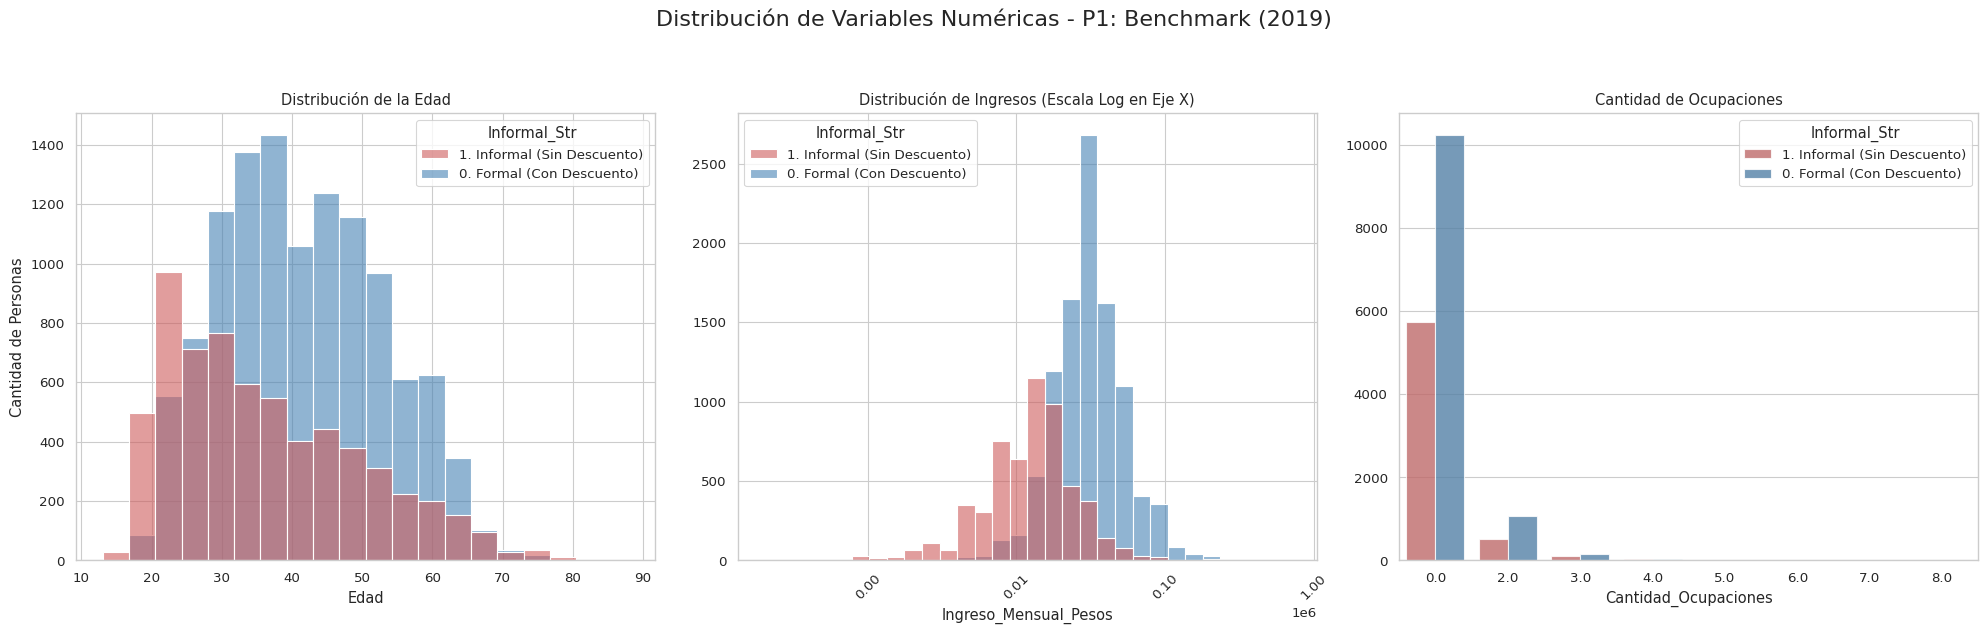

🔹 Mediana Salarial del período P1: Benchmark (2019):


,Ingreso_Mensual_Pesos
Informal_Str,
0. Formal (Con Descuento),"30,000.00 $"
1. Informal (Sin Descuento),"12,500.00 $"



📊 HISTOGRAMAS DEL PERÍODO: P2: Post-Pandemia (2021)


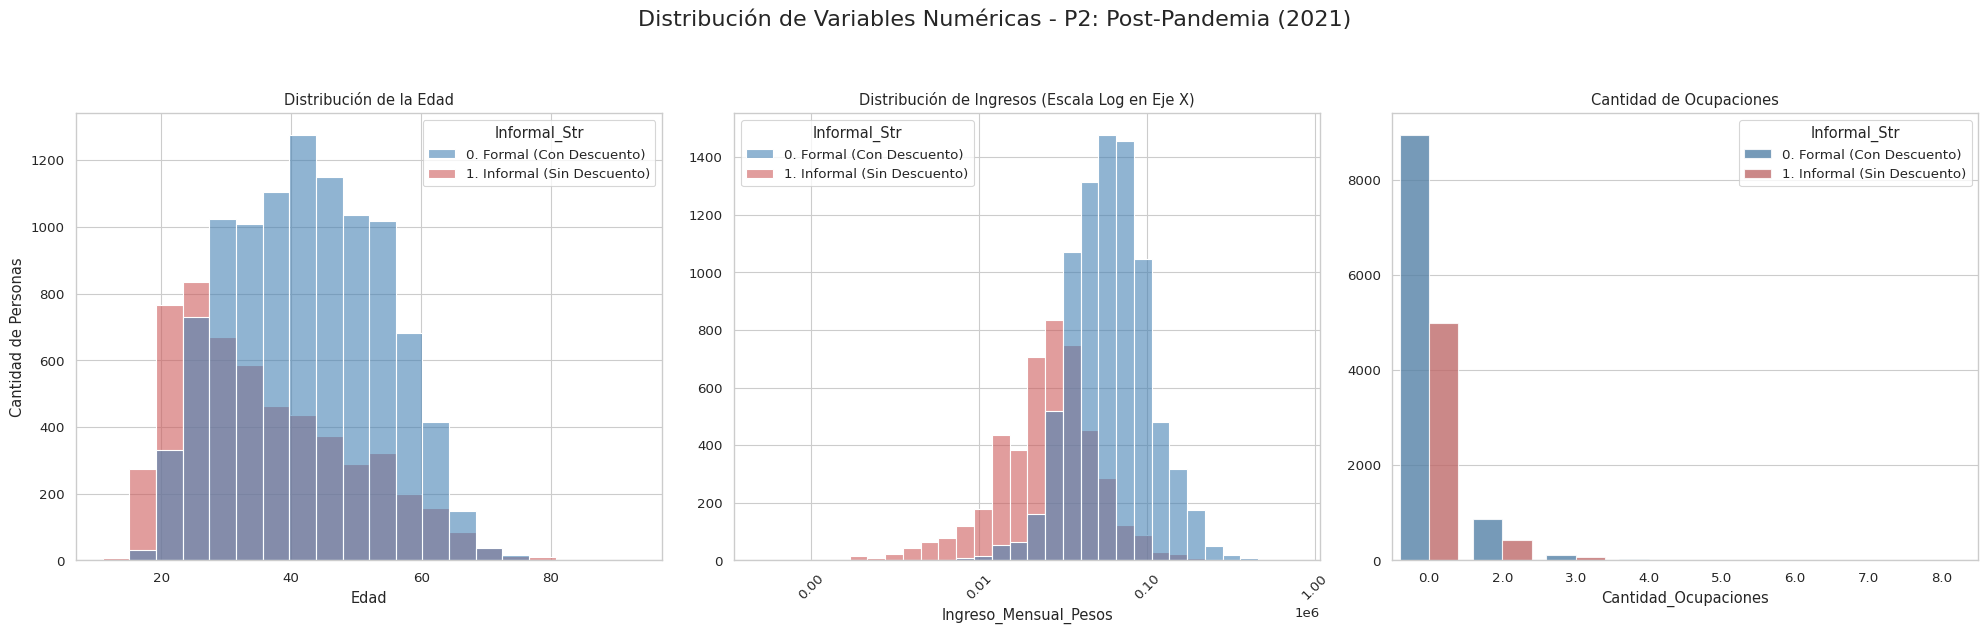

🔹 Mediana Salarial del período P2: Post-Pandemia (2021):


,Ingreso_Mensual_Pesos
Informal_Str,
0. Formal (Con Descuento),"60,000.00 $"
1. Informal (Sin Descuento),"26,450.00 $"



📊 HISTOGRAMAS DEL PERÍODO: P3: Actualidad (2025)


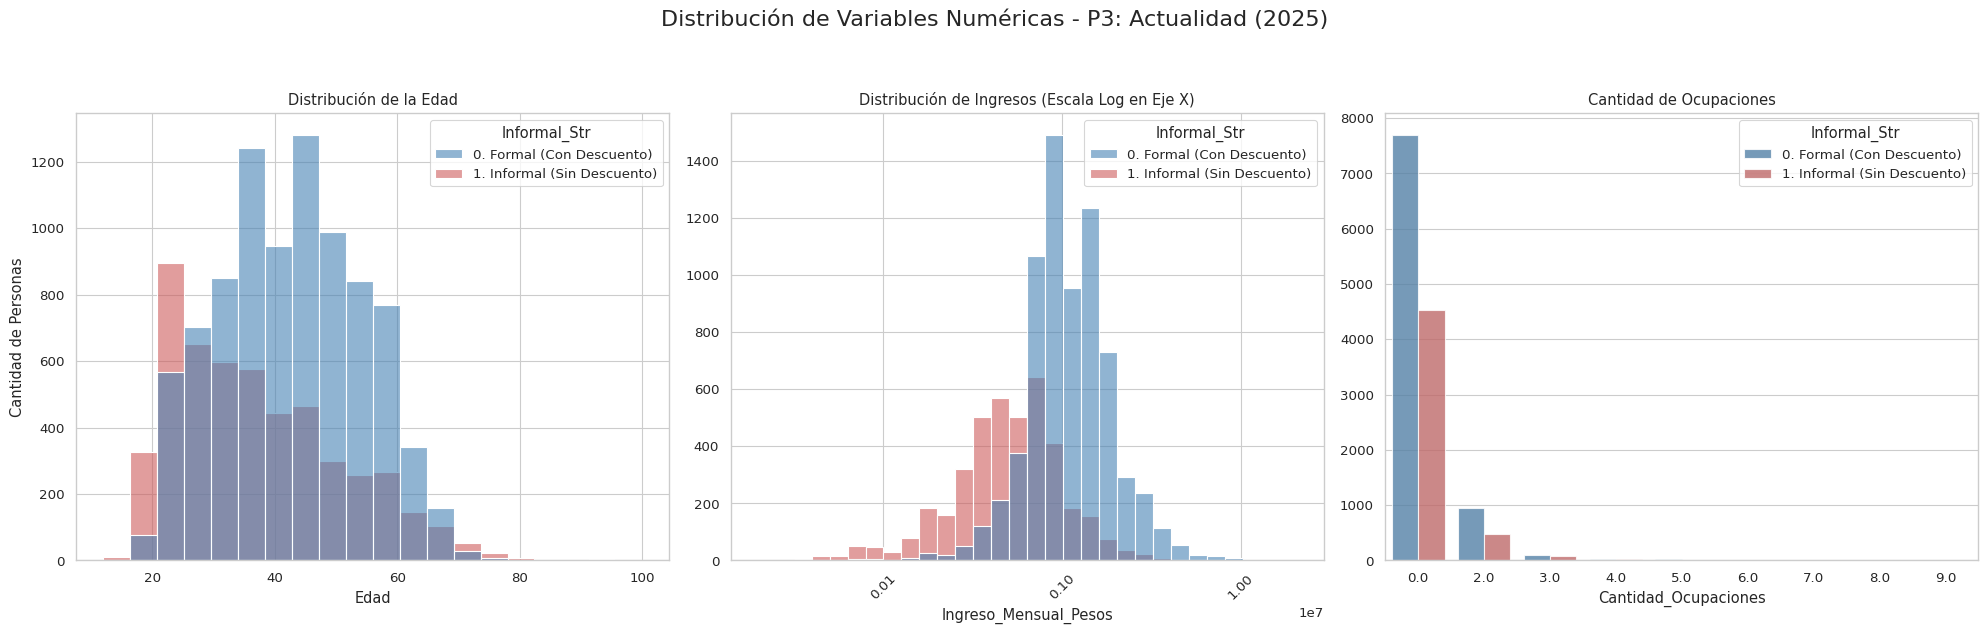

🔹 Mediana Salarial del período P3: Actualidad (2025):


,Ingreso_Mensual_Pesos
Informal_Str,
0. Formal (Con Descuento),"1,100,000.00 $"
1. Informal (Sin Descuento),"530,000.00 $"


In [ ]:
import matplotlib.ticker as ticker
# =====================================================================
# DICCIONARIO DE COLORES ESTRICTO (Coherencia Visual Garantizada)
# =====================================================================
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 3.1 Diccionarios de mapeo oficiales según Diseño de Registro EPH-INDEC
mapeos = {
    'Sexo': {
        1: '1. Varón',
        2: '2. Mujer'
    },
    'Estado_Civil': {
        1: '1. Unido',
        2: '2. Casado',
        3: '3. Separado/divorciado',
        4: '4. Viudo/a',
        5: '5. Soltero/a'
    },
    'Nivel_Educativo': {
        1: '1. Primario incompleto',
        2: '2. Primario completo',
        3: '3. Secundario incompleto',
        4: '4. Secundario completo',
        5: '5. Superior/Univ. incompleto',
        6: '6. Superior/Univ. completo',
        7: '7. Sin instrucción'
    },
    'Region': {
        1: '01. Gran Buenos Aires',
        40: '40. Noroeste',
        41: '41. Noreste',
        42: '42. Cuyo',
        43: '43. Pampeana',
        44: '44. Patagonia'
    },
    'Tamanio_Empresa': {
        1: '1. Estatal',
        2: '2. Privado',
        3: '3. De otro tipo'
    },
    'Informal': {
        0: '0. Formal (Con Descuento)',
        1: '1. Informal (Sin Descuento)'
    }
}

# 3.2 Aplicamos los mapeos creando nuevas columnas descriptivas
for col, mapa in mapeos.items():
    if col in df_t.columns:
        df_t[f'{col}_Str'] = df_t[col].map(mapa).fillna('Sin Dato / NR')

# Lista de las variables descriptivas a graficar
vars_a_graficar = [
    'Sexo_Str', 'Estado_Civil_Str', 'Nivel_Educativo_Str', 'Region_Str',
    'Tamanio_Empresa_Str', 'Lugar_Trabajo_Str', 'Informal_Str', 'Periodo_Hito'
]
print("==================================================")
print("2. HISTOGRAMAS DE VARIABLES NUMÉRICAS POR PERÍODO")
print("==================================================\n")

# 2.1 Forzamos tipos y limpiamos los nulos del INDEC
vars_numericas = ['Edad', 'Ingreso_Mensual_Pesos', 'Cantidad_Ocupaciones']
for col in vars_numericas:
    df_t[col] = pd.to_numeric(df_t[col], errors='coerce')

df_t['Ingreso_Mensual_Pesos'] = df_t['Ingreso_Mensual_Pesos'].replace([-9, 0], np.nan)

# =====================================================================
# 2.2 DICCIONARIO DE COLORES ESTRICTO (Coherencia Visual Garantizada)
# =====================================================================
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue', # Azul
    '1. Informal (Sin Descuento)': 'indianred'  # Rojo
}

# 2.3 Lista de períodos ordenados cronológicamente
periodos = sorted(df_t['Periodo_Hito'].dropna().unique())

# 2.4 Iteramos sobre cada período
for periodo in periodos:
    print("\n" + "="*70)
    print(f"📊 HISTOGRAMAS DEL PERÍODO: {periodo}")
    print("="*70)

    df_periodo = df_t[df_t['Periodo_Hito'] == periodo]

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
    fig.suptitle(f'Distribución de Variables Numéricas - {periodo}', fontsize=16, y=1.05)

    # Gráfico A: EDAD
    sns.histplot(data=df_periodo, x='Edad', hue='Informal_Str',
                 multiple='layer', bins=20, ax=axes[0],
                 palette=colores_informalidad, alpha=0.6)
    axes[0].set_title('Distribución de la Edad')
    axes[0].set_ylabel('Cantidad de Personas')

    # Gráfico B: INGRESOS
    sns.histplot(data=df_periodo, x='Ingreso_Mensual_Pesos', hue='Informal_Str',
                 multiple='layer', log_scale=True, bins=30, ax=axes[1],
                 palette=colores_informalidad, alpha=0.6)
    axes[1].set_title('Distribución de Ingresos (Escala Log en Eje X)')
    axes[1].set_ylabel('')

    # Formateo para números legibles en lugar de científicos
    axes[1].xaxis.set_major_formatter(ticker.ScalarFormatter())
    axes[1].tick_params(axis='x', rotation=45)

    # Gráfico C: CANTIDAD DE OCUPACIONES
    sns.countplot(data=df_periodo, x='Cantidad_Ocupaciones', hue='Informal_Str',
                  ax=axes[2], palette=colores_informalidad, alpha=0.8)
    axes[2].set_title('Cantidad de Ocupaciones')
    axes[2].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # Mediana Salarial
    print(f"🔹 Mediana Salarial del período {periodo}:")
    mediana_salarios = df_periodo.groupby('Informal_Str')['Ingreso_Mensual_Pesos'].median()
    display(pd.DataFrame(mediana_salarios).style.format("{:,.2f} $"))

## Categóricas:

3. DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS (NODOS)



/tmp/ipykernel_28479/2346725861.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_t, y=col, order=orden, ax=axes[i], palette=colores_informalidad)
/tmp/ipykernel_28479/2346725861.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_t, y=col, order=orden, ax=axes[i], palette='magma')


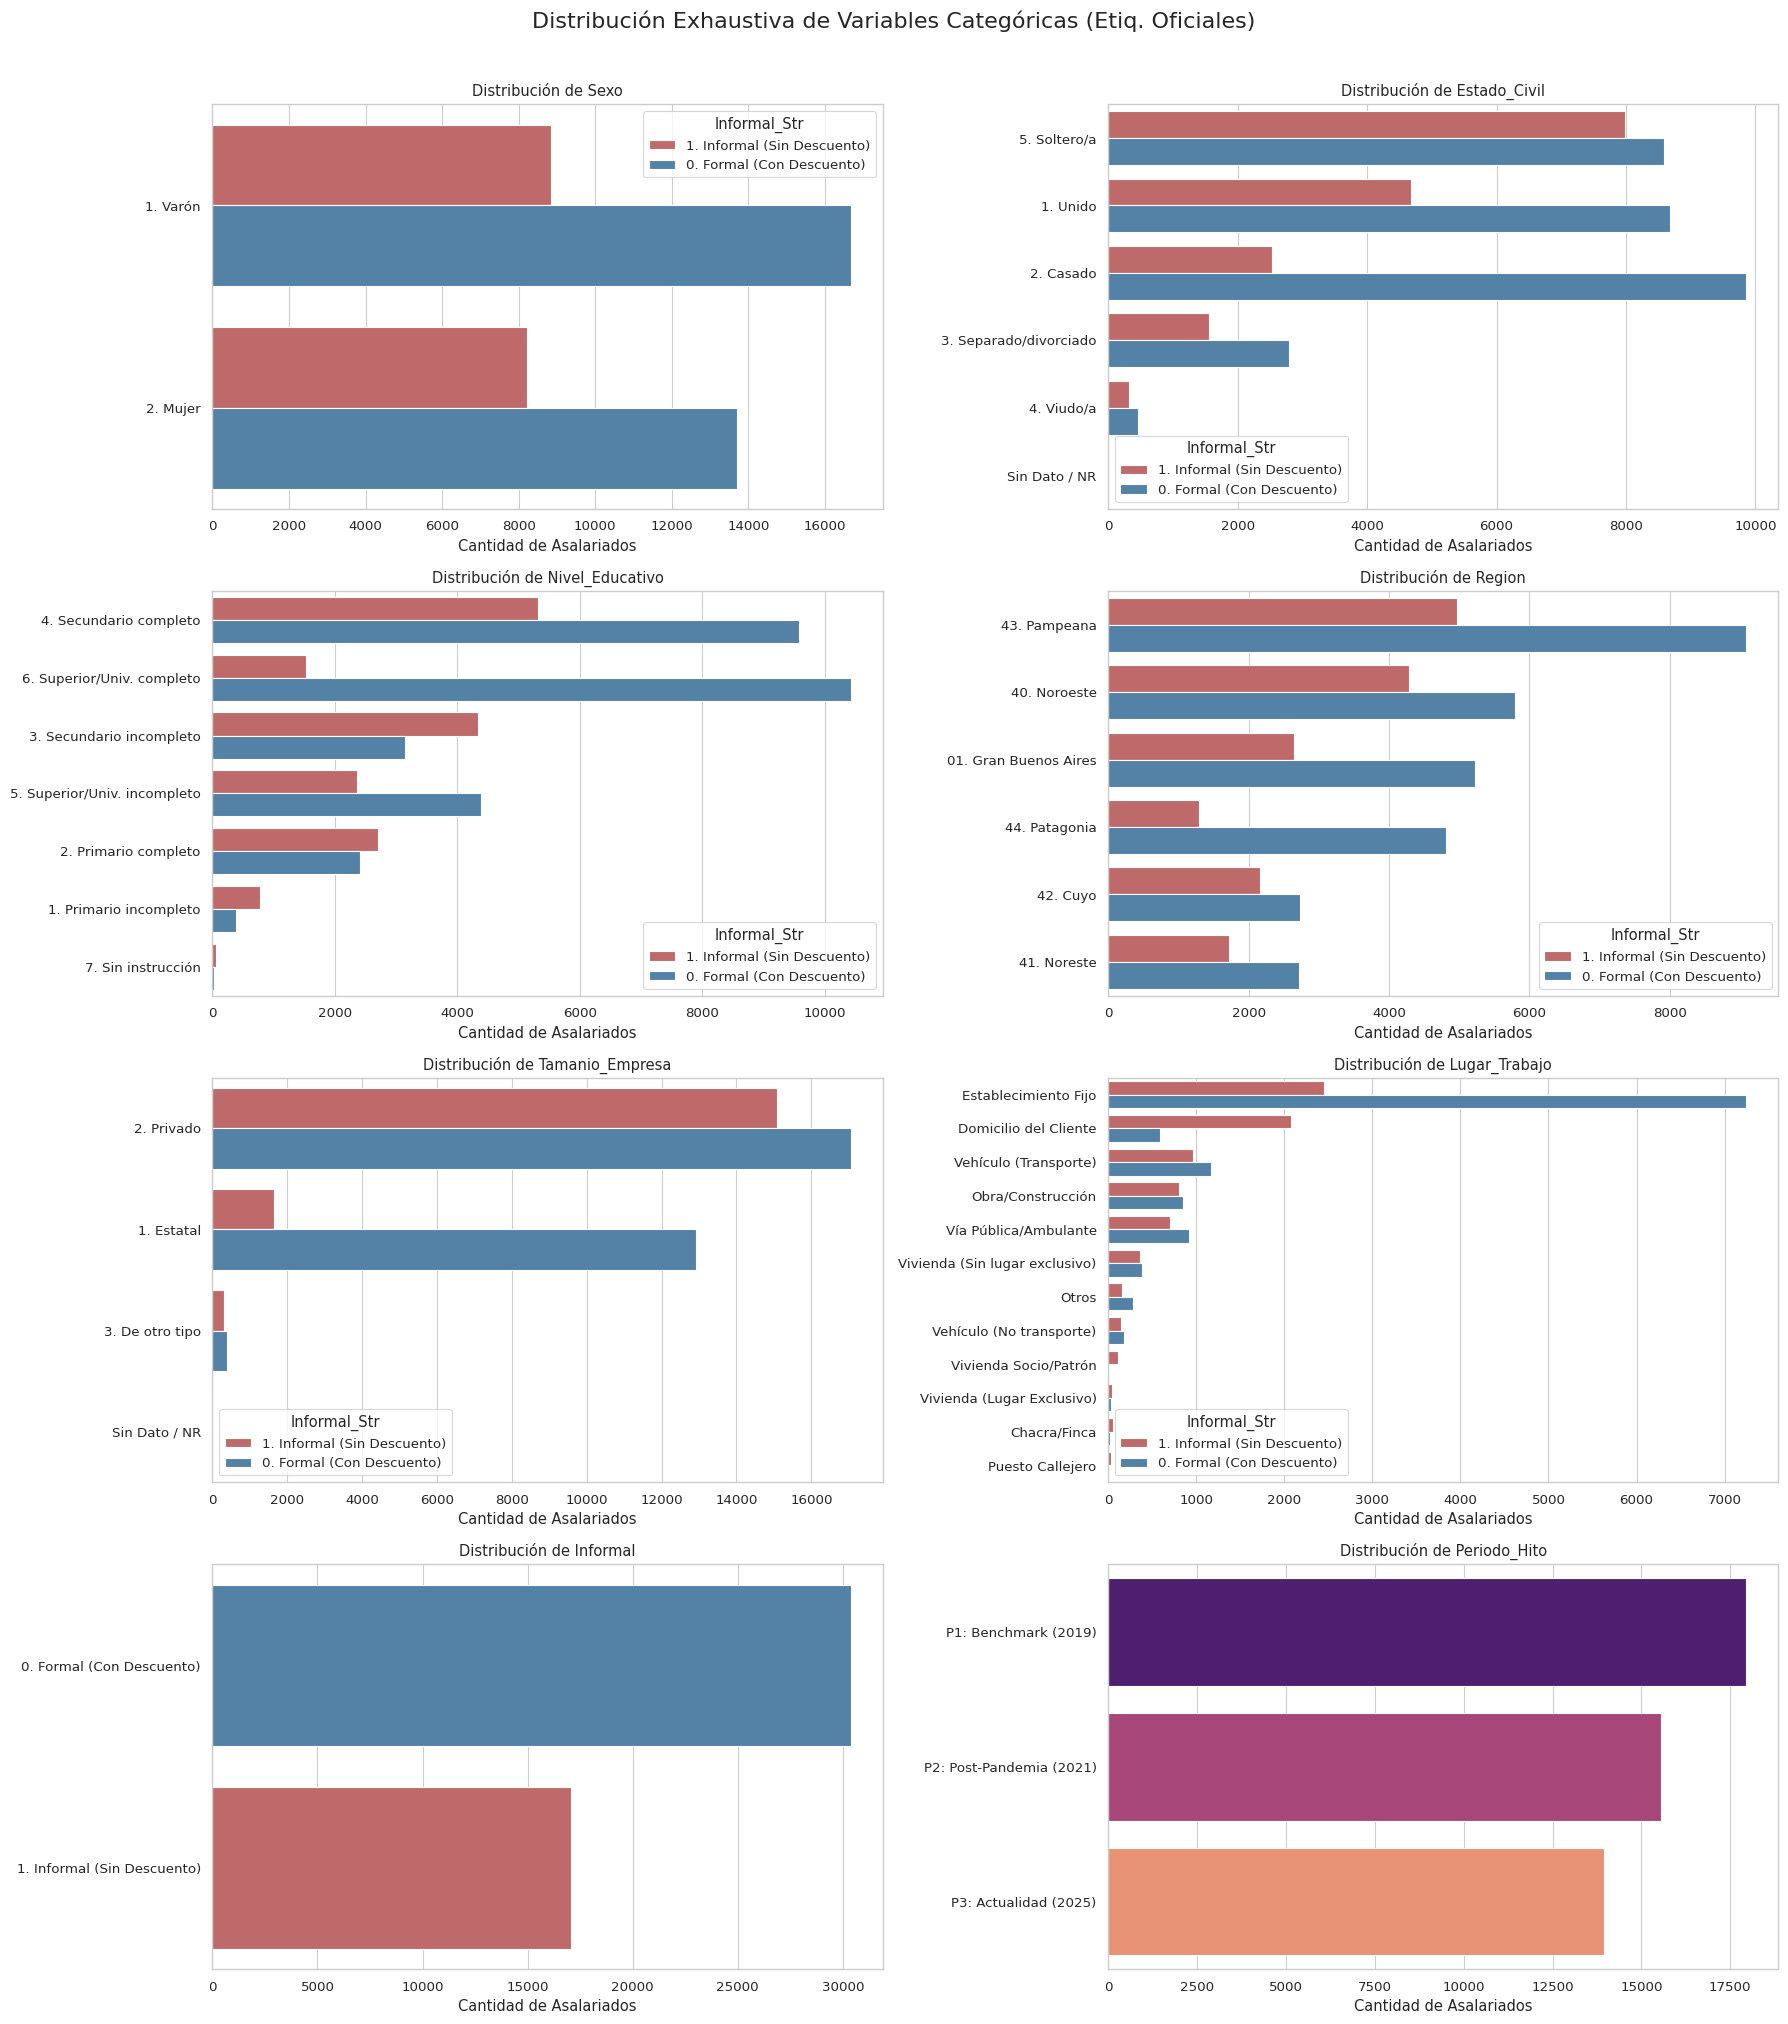


🔹 Resumen Tabulado (Top 3 categorías por variable):

--- Sexo ---


,proportion
Sexo_Str,
1. Varón,53.81%
2. Mujer,46.19%



--- Estado_Civil ---


,proportion
Estado_Civil_Str,
5. Soltero/a,34.92%
1. Unido,28.15%
2. Casado,26.11%



--- Nivel_Educativo ---


...

,proportion
Lugar_Trabajo_Str,
Establecimiento Fijo,49.52%
Domicilio del Cliente,13.61%
Vehículo (Transporte),10.90%



--- Informal ---


,proportion
Informal_Str,
0. Formal (Con Descuento),64.03%
1. Informal (Sin Descuento),35.97%



--- Periodo_Hito ---


,proportion
Periodo_Hito,
P1: Benchmark (2019),37.85%
P2: Post-Pandemia (2021),32.76%
P3: Actualidad (2025),29.39%


In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("3. DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS (NODOS)")
print("==================================================\n")

# =====================================================================
# DICCIONARIO DE COLORES ESTRICTO (Coherencia Visual Garantizada)
# =====================================================================
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 3.1 Diccionarios de mapeo oficiales según Diseño de Registro EPH-INDEC
mapeos = {
    'Sexo': {
        1: '1. Varón',
        2: '2. Mujer'
    },
    'Estado_Civil': {
        1: '1. Unido',
        2: '2. Casado',
        3: '3. Separado/divorciado',
        4: '4. Viudo/a',
        5: '5. Soltero/a'
    },
    'Nivel_Educativo': {
        1: '1. Primario incompleto',
        2: '2. Primario completo',
        3: '3. Secundario incompleto',
        4: '4. Secundario completo',
        5: '5. Superior/Univ. incompleto',
        6: '6. Superior/Univ. completo',
        7: '7. Sin instrucción'
    },
    'Region': {
        1: '01. Gran Buenos Aires',
        40: '40. Noroeste',
        41: '41. Noreste',
        42: '42. Cuyo',
        43: '43. Pampeana',
        44: '44. Patagonia'
    },
    'Tamanio_Empresa': {
        1: '1. Estatal',
        2: '2. Privado',
        3: '3. De otro tipo'
    },
    'Informal': {
        0: '0. Formal (Con Descuento)',
        1: '1. Informal (Sin Descuento)'
    }
}

# 3.2 Aplicamos los mapeos creando nuevas columnas descriptivas
for col, mapa in mapeos.items():
    if col in df_t.columns:
        df_t[f'{col}_Str'] = df_t[col].map(mapa).fillna('Sin Dato / NR')

# Lista de las variables descriptivas a graficar
vars_a_graficar = [
    'Sexo_Str', 'Estado_Civil_Str', 'Nivel_Educativo_Str', 'Region_Str',
    'Tamanio_Empresa_Str', 'Lugar_Trabajo_Str', 'Informal_Str', 'Periodo_Hito'
]

# 3.3 Configuración dinámica de la grilla de gráficos
n_cols = 2
n_rows = math.ceil(len(vars_a_graficar) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Distribución Exhaustiva de Variables Categóricas (Etiq. Oficiales)', fontsize=16, y=1.01)

axes = axes.flatten()

for i, col in enumerate(vars_a_graficar):
    if col in df_t.columns:
        # Ordenamos por cantidad de casos de mayor a menor
        orden = df_t[col].value_counts().index

        # Lógica para aplicar los colores sin romper el gráfico
        if col == 'Informal_Str':
            # Si es el Target, aplicamos la paleta directamente
            sns.countplot(data=df_t, y=col, order=orden, ax=axes[i], palette=colores_informalidad)
        elif col == 'Periodo_Hito':
            # Para el período histórico dejamos una paleta genérica ya que no es un atributo de la persona
            sns.countplot(data=df_t, y=col, order=orden, ax=axes[i], palette='magma')
        else:
            # Para el resto de las variables, subdividimos por informalidad (hue) para usar el rojo y azul
            sns.countplot(data=df_t, y=col, hue='Informal_Str', order=orden, ax=axes[i], palette=colores_informalidad)

        axes[i].set_title(f'Distribución de {col.replace("_Str", "")}')
        axes[i].set_xlabel('Cantidad de Asalariados')
        axes[i].set_ylabel('')

# Ocultamos los subplots sobrantes si la cantidad de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3.4 Reporte tabulado de la distribución categórica
print("\n🔹 Resumen Tabulado (Top 3 categorías por variable):")
for col in vars_a_graficar:
    if col in df_t.columns:
        print(f"\n--- {col.replace('_Str', '')} ---")
        display(df_t[col].value_counts(normalize=True).head(3).apply(lambda x: f"{x*100:.2f}%"))

DISTRIBUCIÓN DE INFORMALIDAD POR REGIÓN



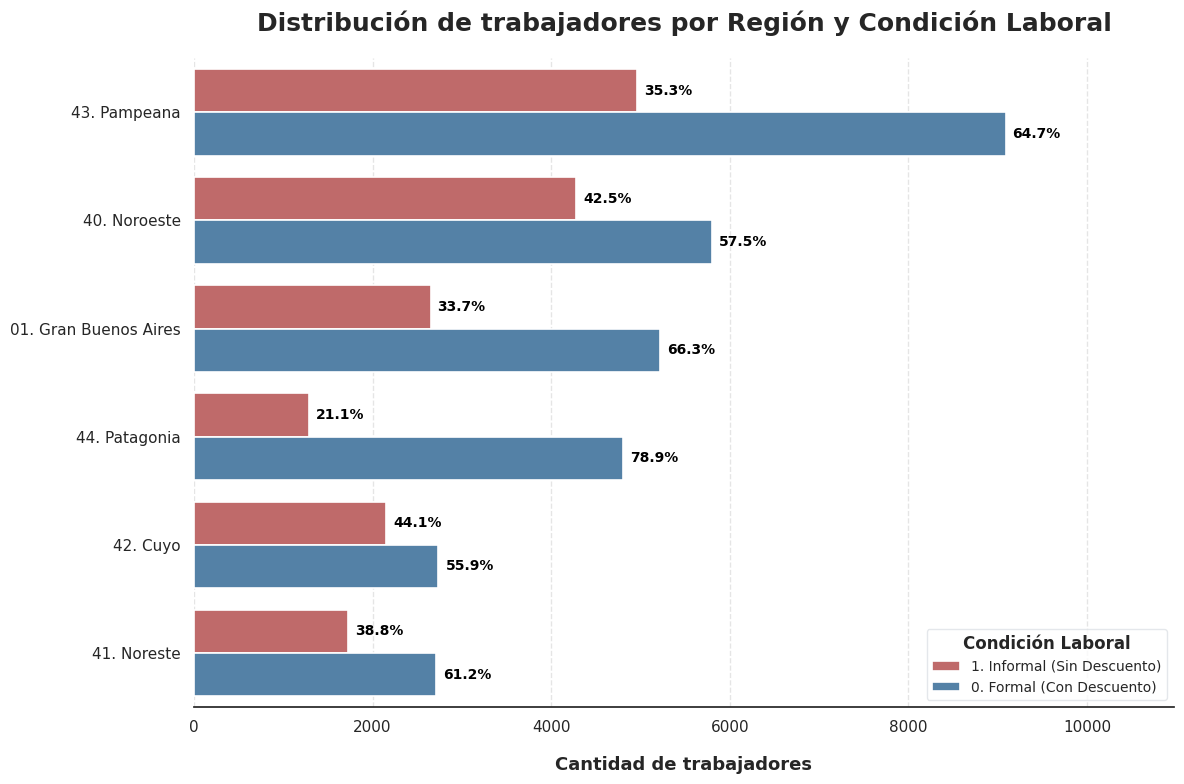


🔹 Resumen Tabulado (Distribución general por Región):


,proportion
Region_Str,
43. Pampeana,29.62%
40. Noroeste,21.24%
01. Gran Buenos Aires,16.60%
44. Patagonia,12.86%
42. Cuyo,10.32%
41. Noreste,9.36%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("==================================================")
print("DISTRIBUCIÓN DE INFORMALIDAD POR REGIÓN")
print("==================================================\n")

# 1. CONFIGURACIÓN ESTÉTICA
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style="white")

# 2. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 3. MAPEOS DESCRIPTIVOS (Región y Target)
mapa_region = {
    1: '01. Gran Buenos Aires',
    40: '40. Noroeste',
    41: '41. Noreste',
    42: '42. Cuyo',
    43: '43. Pampeana',
    44: '44. Patagonia'
}

mapa_informal = {
    0: '0. Formal (Con Descuento)',
    1: '1. Informal (Sin Descuento)'
}

# Aplicamos los mapeos
if 'Region' in df_t.columns:
    df_t['Region_Str'] = df_t['Region'].map(mapa_region).fillna('Sin Dato / NR')

if 'Informal' in df_t.columns and 'Informal_Str' not in df_t.columns:
    df_t['Informal_Str'] = df_t['Informal'].map(mapa_informal).fillna('Sin Dato / NR')

# 4. ORDENAMIENTO (De mayor a menor cantidad de casos)
orden_region = df_t['Region_Str'].value_counts().index

# 5. CREACIÓN DEL GRÁFICO
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

sns.countplot(
    data=df_t,
    y='Region_Str',
    hue='Informal_Str',
    order=orden_region,
    palette=colores_informalidad,
    edgecolor='white',
    linewidth=1.2,
    ax=ax
)

# ---------------------------------------------------------
# LÓGICA DE PORCENTAJES RELATIVOS POR REGIÓN
# ---------------------------------------------------------
num_regiones = len(orden_region)

# Calculamos el total de trabajadores por cada región (suma de formal + informal en cada fila)
totales_por_region = [
    sum(container.datavalues[i] for container in ax.containers)
    for i in range(num_regiones)
]

# Iteramos sobre los contenedores (las barras azules y rojas)
for container in ax.containers:
    etiquetas = []
    for i, valor in enumerate(container.datavalues):
        total_fila = totales_por_region[i]
        if total_fila > 0 and valor > 0:
            # Calculamos el % respecto a esa región específica
            porcentaje = (valor / total_fila) * 100
            etiquetas.append(f'{porcentaje:.1f}%')
        else:
            etiquetas.append('')

    # Agregamos las etiquetas al final de cada barra
    ax.bar_label(container, labels=etiquetas, padding=5, fontsize=10, color='black', fontweight='bold')

# Ampliamos el eje X para que los textos no se corten
xmax = ax.get_xlim()[1]
ax.set_xlim(0, xmax * 1.15)
# ---------------------------------------------------------

# 6. DETALLES ESTÉTICOS Y LEYENDA
ax.set_title('Distribución de trabajadores por Región y Condición Laboral', fontsize=18, pad=20)
ax.set_xlabel('Cantidad de trabajadores', fontsize=13, labelpad=15)
ax.set_ylabel('')

# Ubicamos la leyenda
ax.legend(
    title="Condición Laboral",
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='#dee2e6',
    fontsize=10,
    title_fontproperties={'weight': 'bold'}
)

# Grilla vertical sutil
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

sns.despine(left=True)
plt.tight_layout()
plt.show()

# 7. REPORTE TABULADO
print("\n🔹 Resumen Tabulado (Distribución general por Región):")
display(df_t['Region_Str'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

DISTRIBUCIÓN POR PERÍODO HITO



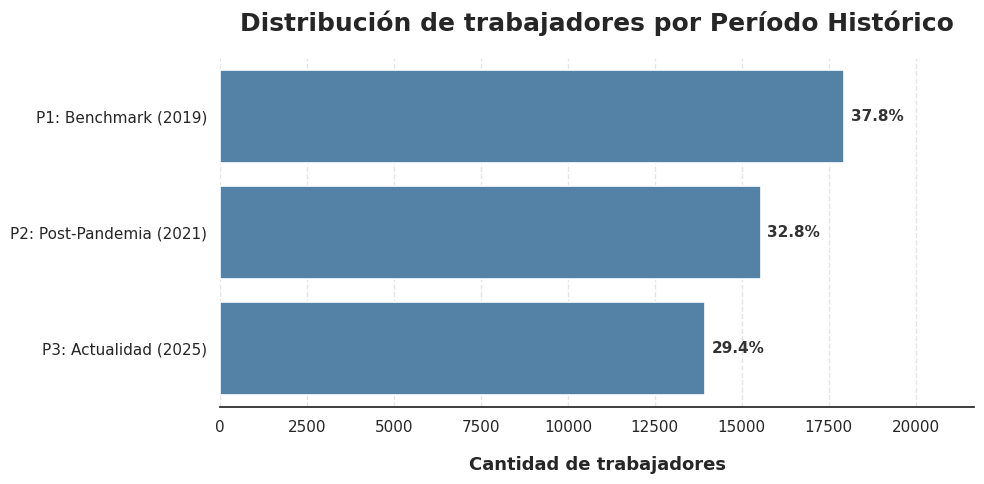


🔹 Resumen Tabulado de la distribución:


,Cantidad,Porcentaje
Periodo_Hito,,
P1: Benchmark (2019),17953,37.85%
P2: Post-Pandemia (2021),15539,32.76%
P3: Actualidad (2025),13943,29.39%


In [ ]:
print("==================================================")
print("DISTRIBUCIÓN POR PERÍODO HITO")
print("==================================================\n")

# 1. CONFIGURACIÓN ESTÉTICA
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style="white")

# Verificamos que la columna exista
if 'Periodo_Hito' in df_t.columns:

    # 2. ORDENAMIENTO
    orden_periodo = sorted(df_t['Periodo_Hito'].dropna().unique())

    # 3. CREACIÓN DEL GRÁFICO
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

    sns.countplot(
        data=df_t,
        y='Periodo_Hito',
        order=orden_periodo,
        color='steelblue',
        edgecolor='white',
        linewidth=1.2,
        ax=ax
    )

    # 4. ETIQUETAS DE PORCENTAJE SOBRE LAS BARRAS
    # Calculamos el total de registros válidos para sacar el porcentaje
    total_observaciones = len(df_t['Periodo_Hito'].dropna())

    for container in ax.containers:
        # Generamos una lista de textos con el porcentaje formateado a 1 decimal
        etiquetas = [f'{(valor / total_observaciones) * 100:.1f}%' for valor in container.datavalues]
        ax.bar_label(container, labels=etiquetas, padding=5, fontsize=11, color='#333333', fontweight='bold')

    # Ampliamos un 15% el eje X para que los porcentajes no queden pegados al borde de la imagen
    xmax = ax.get_xlim()[1]
    ax.set_xlim(0, xmax * 1.15)

    # 5. DETALLES FINALES
    ax.set_title('Distribución de trabajadores por Período Histórico', fontsize=18, pad=20)
    ax.set_xlabel('Cantidad de trabajadores', fontsize=13, labelpad=15)
    ax.set_ylabel('')

    # Grilla vertical sutil para facilitar la lectura
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True)

    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

    # 6. REPORTE TABULADO
    print("\n🔹 Resumen Tabulado de la distribución:")

    # Mostramos cantidad real y porcentaje
    resumen = pd.DataFrame({
        'Cantidad': df_t['Periodo_Hito'].value_counts(),
        'Porcentaje': df_t['Periodo_Hito'].value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%")
    }).reindex(orden_periodo)

    display(resumen)
else:
    print("La columna 'Periodo_Hito' no se encuentra en el DataFrame.")

DISTRIBUCIÓN DE INFORMALIDAD POR ESTADO CIVIL



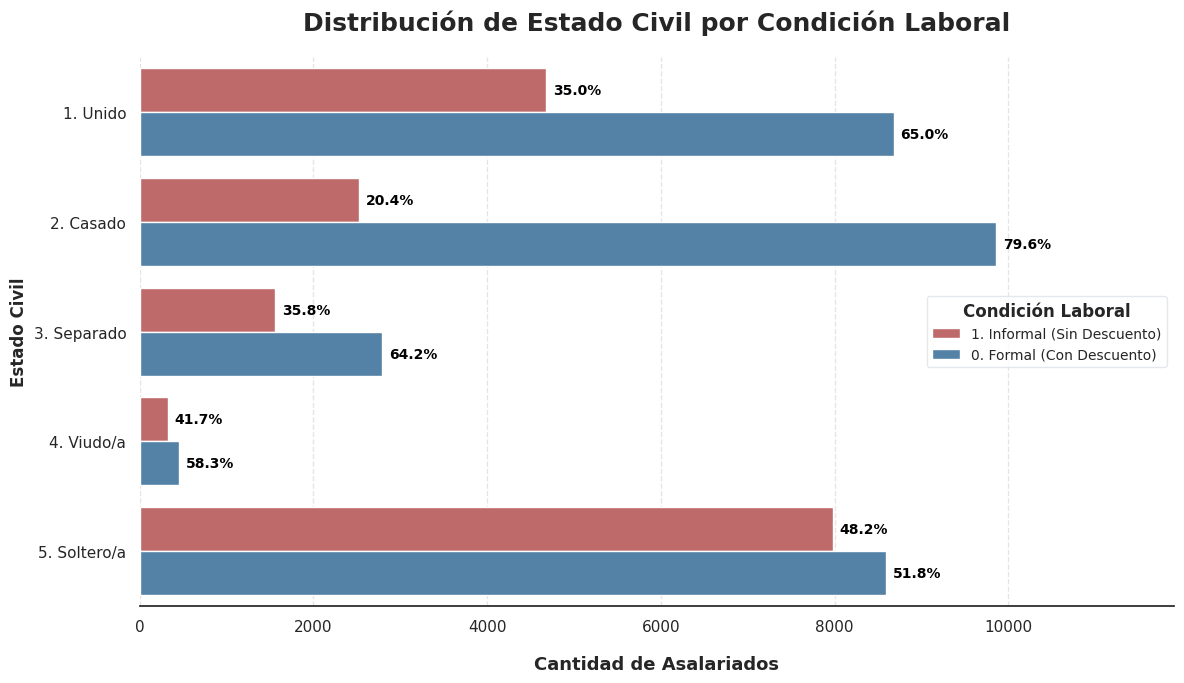


🔹 Resumen Tabulado (Ordenado según el gráfico):


,count
Estado_Civil_Str,
1. Unido,13353 casos
2. Casado,12387 casos
3. Separado,4348 casos
4. Viudo/a,779 casos
5. Soltero/a,16565 casos


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("==================================================")
print("DISTRIBUCIÓN DE INFORMALIDAD POR ESTADO CIVIL")
print("==================================================\n")

# 1. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 2. CONFIGURACIÓN ESTÉTICA
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style="white")

# 3. MAPEOS DESCRIPTIVOS (Con categoría 3 modificada)
mapa_estado_civil = {
    1: '1. Unido',
    2: '2. Casado',
    3: '3. Separado',   # <--- Cambio aplicado aquí
    4: '4. Viudo/a',
    5: '5. Soltero/a'
}

mapa_informal = {
    0: '0. Formal (Con Descuento)',
    1: '1. Informal (Sin Descuento)'
}

# Aplicamos los mapeos a las columnas
if 'Estado_Civil' in df_t.columns:
    df_t['Estado_Civil_Str'] = df_t['Estado_Civil'].map(mapa_estado_civil).fillna('Sin Dato / NR')

if 'Informal' in df_t.columns and 'Informal_Str' not in df_t.columns:
    df_t['Informal_Str'] = df_t['Informal'].map(mapa_informal).fillna('Sin Dato / NR')

# 4. LÓGICA DE ORDENAMIENTO PERSONALIZADO
counts = df_t['Estado_Civil_Str'].value_counts()
label_nulo = 'Sin Dato / NR'
categorias_con_datos = [
 '1. Unido',
 '2. Casado',
 '3. Separado',
 '4. Viudo/a',
 '5. Soltero/a'
]
orden_final = categorias_con_datos

# 5. CREACIÓN DEL GRÁFICO
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

sns.countplot(
    data=df_t,
    y='Estado_Civil_Str',
    hue='Informal_Str',
    order=orden_final,
    palette=colores_informalidad,
    edgecolor='white',
    linewidth=1,
    ax=ax
)

# ---------------------------------------------------------
# LÓGICA DE PORCENTAJES RELATIVOS (Agregado)
# ---------------------------------------------------------
num_categorias = len(orden_final)

# Calculamos el total de observaciones por cada estado civil (sumando la barra azul y roja de esa fila)
totales_por_estado = [
    sum(container.datavalues[i] for container in ax.containers)
    for i in range(num_categorias)
]

# Iteramos sobre los contenedores para inyectar la etiqueta calculada
for container in ax.containers:
    etiquetas = []
    for i, valor in enumerate(container.datavalues):
        total_fila = totales_por_estado[i]
        if total_fila > 0 and valor > 0:
            # Calculamos el % sobre el total de ese estado civil
            porcentaje = (valor / total_fila) * 100
            etiquetas.append(f'{porcentaje:.1f}%')
        else:
            etiquetas.append('')

    ax.bar_label(container, labels=etiquetas, padding=5, fontsize=10, color='black', fontweight='bold')

# Ampliamos el límite del eje X para que los porcentajes no queden cortados
xmax = ax.get_xlim()[1]
ax.set_xlim(0, xmax * 1.15)
# ---------------------------------------------------------

# 6. AJUSTE DE LA LEYENDA
ax.legend(
    title="Condición Laboral",
    loc='center right',
    frameon=True,
    facecolor='white',
    edgecolor='#dee2e6',
    fontsize=10,
    title_fontproperties={'weight': 'bold'}
)

# 7. DETALLES FINALES
ax.set_title('Distribución de Estado Civil por Condición Laboral', fontsize=18, pad=20)
ax.set_xlabel('Cantidad de Asalariados', fontsize=13, labelpad=15)
ax.set_ylabel('Estado Civil')

ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

sns.despine(left=True)
plt.tight_layout()
plt.show()

# 8. REPORTE TABULADO
print("\n🔹 Resumen Tabulado (Ordenado según el gráfico):")
display(df_t['Estado_Civil_Str'].value_counts().reindex(orden_final).apply(lambda x: f"{x} casos"))

DISTRIBUCIÓN DE INFORMALIDAD POR ESTADO CIVIL



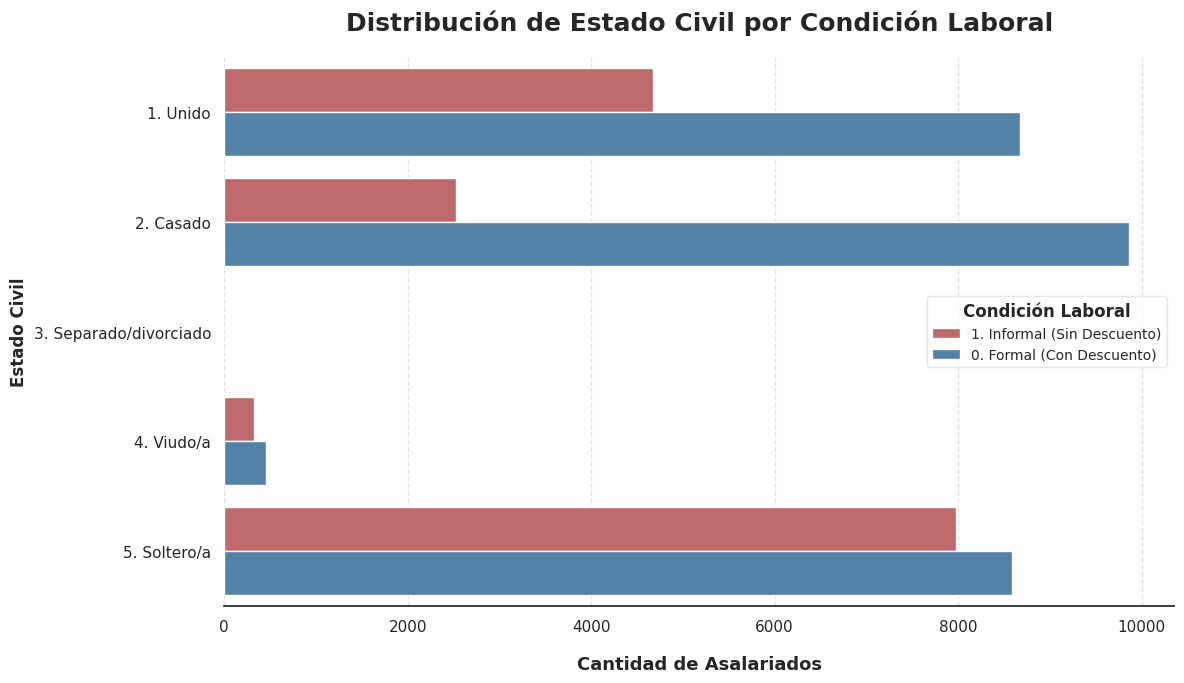


🔹 Resumen Tabulado (Ordenado según el gráfico):


,count
Estado_Civil_Str,
1. Unido,13353.0 casos
2. Casado,12387.0 casos
3. Separado/divorciado,nan casos
4. Viudo/a,779.0 casos
5. Soltero/a,16565.0 casos


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("==================================================")
print("DISTRIBUCIÓN DE INFORMALIDAD POR ESTADO CIVIL")
print("==================================================\n")

# 1. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 2. CONFIGURACIÓN ESTÉTICA
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style="white")

# 3. LÓGICA DE ORDENAMIENTO PERSONALIZADO
# Obtenemos las categorías ordenadas por frecuencia (descendente)
counts = df_t['Estado_Civil_Str'].value_counts()

# Filtramos las categorías para separar el nulo del resto
categorias_con_datos = [
 '1. Unido',
 '2. Casado',
 '3. Separado/divorciado',
 '4. Viudo/a','5. Soltero/a']

# Creamos la lista final: primero los datos ordenados, al final el nulo
orden_final = categorias_con_datos

# 4. CREACIÓN DEL GRÁFICO
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

sns.countplot(
    data=df_t,
    y='Estado_Civil_Str',
    hue='Informal_Str',
    order=orden_final,
    palette=colores_informalidad,
    edgecolor='white',
    linewidth=1,
    ax=ax
)

# 5. AJUSTE DE LA LEYENDA (Esquina inferior derecha)
ax.legend(
    title="Condición Laboral",
    loc='center right',
    frameon=True,
    facecolor='white',
    edgecolor='#dee2e6',
    fontsize=10,
    title_fontproperties={'weight': 'bold'}
)

# 6. DETALLES FINALES
ax.set_title('Distribución de Estado Civil por Condición Laboral', fontsize=18, pad=20)
ax.set_xlabel('Cantidad de Asalariados', fontsize=13, labelpad=15)
ax.set_ylabel('Estado Civil')

# Agregamos una grilla vertical muy sutil
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

sns.despine(left=True)
plt.tight_layout()
plt.show()

# 7. REPORTE TABULADO (Conserva el mismo orden del gráfico)
print("\n🔹 Resumen Tabulado (Ordenado según el gráfico):")
display(df_t['Estado_Civil_Str'].value_counts().reindex(orden_final).apply(lambda x: f"{x} casos"))

DISTRIBUCIÓN DE INFORMALIDAD POR NIVEL EDUCATIVO



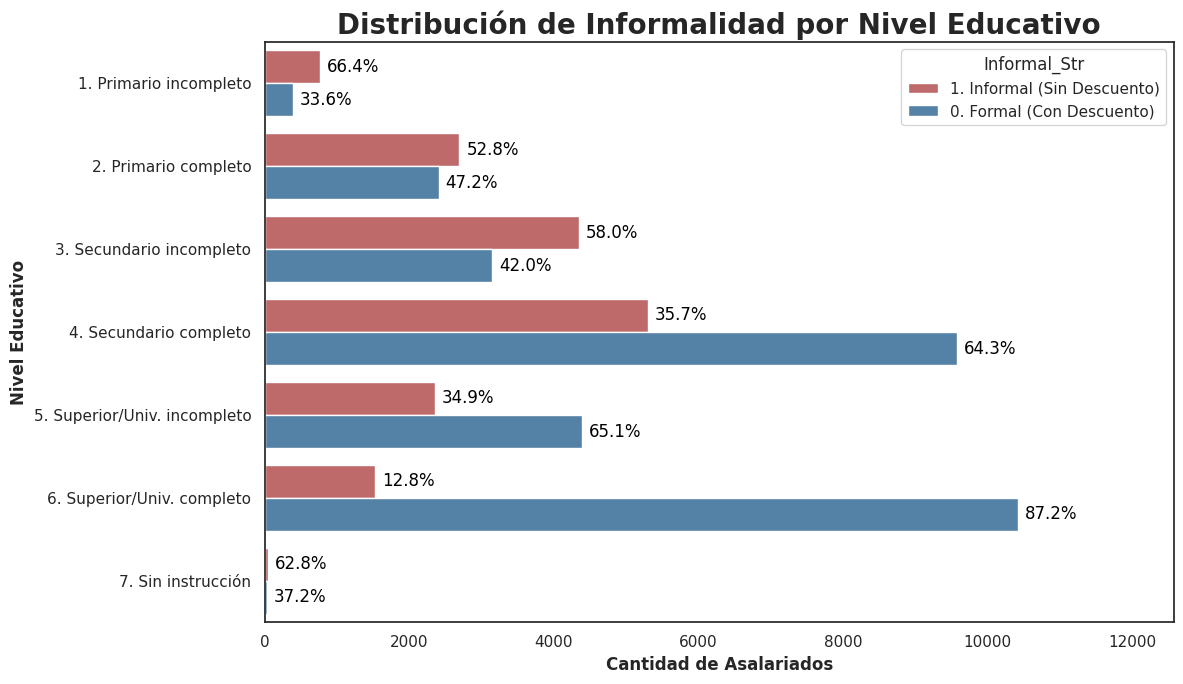


🔹 Resumen Tabulado (Validación de los porcentajes del gráfico):


Informal_Str,0. Formal (Con Descuento),1. Informal (Sin Descuento)
Nivel_Educativo_Str,,
1. Primario incompleto,33.59%,66.41%
2. Primario completo,47.19%,52.81%
3. Secundario incompleto,42.01%,57.99%
4. Secundario completo,64.35%,35.65%
5. Superior/Univ. incompleto,65.06%,34.94%
6. Superior/Univ. completo,87.2%,12.8%
7. Sin instrucción,37.21%,62.79%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("==================================================")
print("DISTRIBUCIÓN DE INFORMALIDAD POR NIVEL EDUCATIVO")
print("==================================================\n")

# 1. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 2. Mapeo exclusivo para Nivel Educativo
mapa_educacion = {
    1: '1. Primario incompleto',
    2: '2. Primario completo',
    3: '3. Secundario incompleto',
    4: '4. Secundario completo',
    5: '5. Superior/Univ. incompleto',
    6: '6. Superior/Univ. completo',
    7: '7. Sin instrucción'
}

if 'Nivel_Educativo' in df_t.columns:
    df_t['Nivel_Educativo_Str'] = df_t['Nivel_Educativo'].map(mapa_educacion).fillna('Sin Dato / NR')

# 3. Definir el orden lógico (ascendente)
orden_educacion = sorted(df_t['Nivel_Educativo_Str'].dropna().unique())

# 4. Creación del gráfico
plt.figure(figsize=(12, 7))

ax = sns.countplot(
    data=df_t,
    y='Nivel_Educativo_Str',
    hue='Informal_Str',
    order=orden_educacion,
    palette=colores_informalidad
)

plt.title('Distribución de Informalidad por Nivel Educativo', fontsize=20)
plt.xlabel('Cantidad de Asalariados')
plt.ylabel('Nivel Educativo')

# 5. Lógica para calcular porcentajes relativos por categoría (fila)
# Obtenemos la cantidad de categorías en el eje Y
num_categorias = len(orden_educacion)

# Calculamos el total de observaciones por cada nivel educativo sumando las barras de ese nivel
totales_por_nivel = [
    sum(container.datavalues[i] for container in ax.containers)
    for i in range(num_categorias)
]

# Iteramos sobre cada contenedor (Formal e Informal) para inyectar la etiqueta
for container in ax.containers:
    etiquetas = []
    for i, valor in enumerate(container.datavalues):
        total_fila = totales_por_nivel[i]
        if total_fila > 0 and valor > 0:
            # Calculamos el % sobre el total de ese nivel educativo
            porcentaje = (valor / total_fila) * 100
            etiquetas.append(f'{porcentaje:.1f}%')
        else:
            etiquetas.append('')

    ax.bar_label(container, labels=etiquetas, padding=5, fontsize=12, color='black')

# Ampliamos el eje X para que los porcentajes no se corten visualmente
xmax = ax.get_xlim()[1]
ax.set_xlim(0, xmax * 1.15)

plt.tight_layout()
plt.show()

# 6. Reporte tabulado cruzado para validación
print("\n🔹 Resumen Tabulado (Validación de los porcentajes del gráfico):")
tabla_cruzada = pd.crosstab(df_t['Nivel_Educativo_Str'], df_t['Informal_Str'], normalize='index') * 100
display(tabla_cruzada.round(2).astype(str) + '%')

## Calidad de datos y limpieza:

In [ ]:
print("==================================================")
print("2. LIMPIEZA Y CALIDAD DE LOS DATOS (EPH)")
print("==================================================\n")

df_clean = df_t.copy()

# 2.1 Detección y eliminación de duplicados
columnas_pk = ['ID_Vivienda', 'ID_Hogar', 'ID_Persona', 'Periodo_Hito']
duplicados = df_clean.duplicated(subset=columnas_pk).sum()
print(f"🔍 Registros duplicados detectados: {duplicados}")
if duplicados > 0:
    df_clean = df_clean.drop_duplicates(subset=columnas_pk)
    print("✅ Duplicados eliminados.")

# 2.2 Tratamiento de códigos "No sabe / No responde" típicos del INDEC
# En lugar de dejarlos como categorías válidas, los pasamos a NaN
columnas_cat = ['Nivel_Educativo', 'Sexo', 'Estado_Civil', 'Lugar_Trabajo', 'Tamanio_Empresa']
for col in columnas_cat:
    df_clean[col] = df_clean[col].replace([9, 99], np.nan)

# Ingresos: El INDEC usa -9 para NS/NC, y 0 para quienes no percibieron ingresos.
# Como filtramos asalariados ocupados, un ingreso 0 es anómalo para el análisis causal.
df_clean['Ingreso_Mensual_Pesos'] = df_clean['Ingreso_Mensual_Pesos'].replace([-9, 0], np.nan)

# 2.3 Reporte de Valores Nulos
print("\n📊 Porcentaje de Valores Nulos por Variable:")
nulos_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
display(nulos_pct[nulos_pct > 0].sort_values(ascending=False).round(2))


2. LIMPIEZA Y CALIDAD DE LOS DATOS (EPH)

🔍 Registros duplicados detectados: 0

📊 Porcentaje de Valores Nulos por Variable:


,0
Lugar_Trabajo_Str,58.72
Ingreso_Mensual_Pesos,16.34
Lugar_Trabajo,3.44
Tamanio_Empresa,0.03
Estado_Civil,0.01


Nota técnica: La variable PP04B_COD es nominal, es decir, el sector 20 no es "el doble" que el sector 10. Por lo tanto, la incluimos en el análisis de nulos, pero la excluimos de la matriz de correlación de Spearman, ya que esta última solo mide relaciones monótonas/ordinales

🔍 1. Analizando Calidad de Datos (Valores Faltantes)

Tabla de Datos Faltantes (Ordenada por criticidad):


,Cantidad de Nulos,Porcentaje (%)
ln_Ingreso,7753,16.34%
Ingreso_Mensual_Pesos,7753,16.34%
Sexo,0,0.00%
Estado_Civil,0,0.00%
Edad,0,0.00%
Nivel_Educativo,0,0.00%
Region,0,0.00%
Cantidad_Ocupaciones,0,0.00%
Tamanio_Empresa,0,0.00%
Rama_Actividad_CAES,0,0.00%



Porcentaje de asalariados que no declaran ingresos (Sesgo de No-Respuesta):


Informal_Str,Formal,Informal
Periodo_Hito,,
P1: Benchmark (2019),12.7%,12.2%
P2: Post-Pandemia (2021),17.7%,15.5%
P3: Actualidad (2025),20.1%,21.3%



📊 2. Analizando Distribuciones y No Linealidad


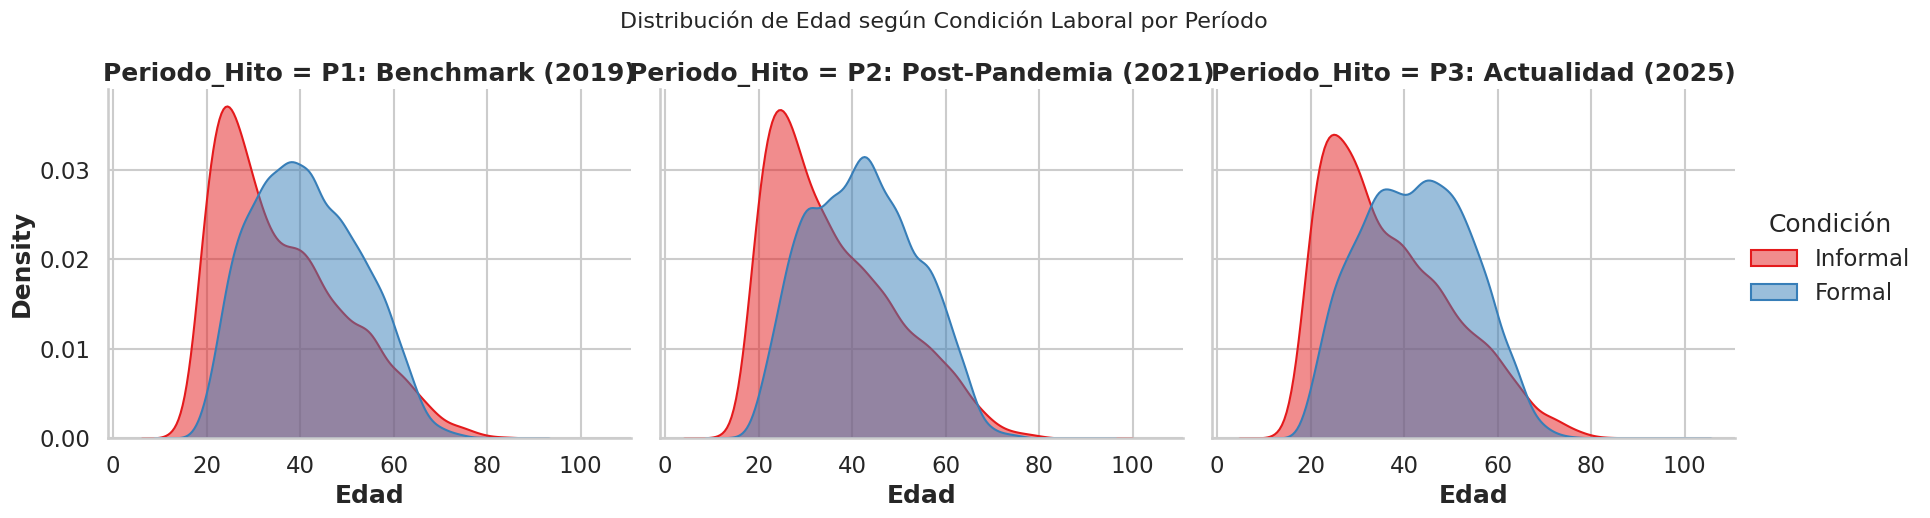

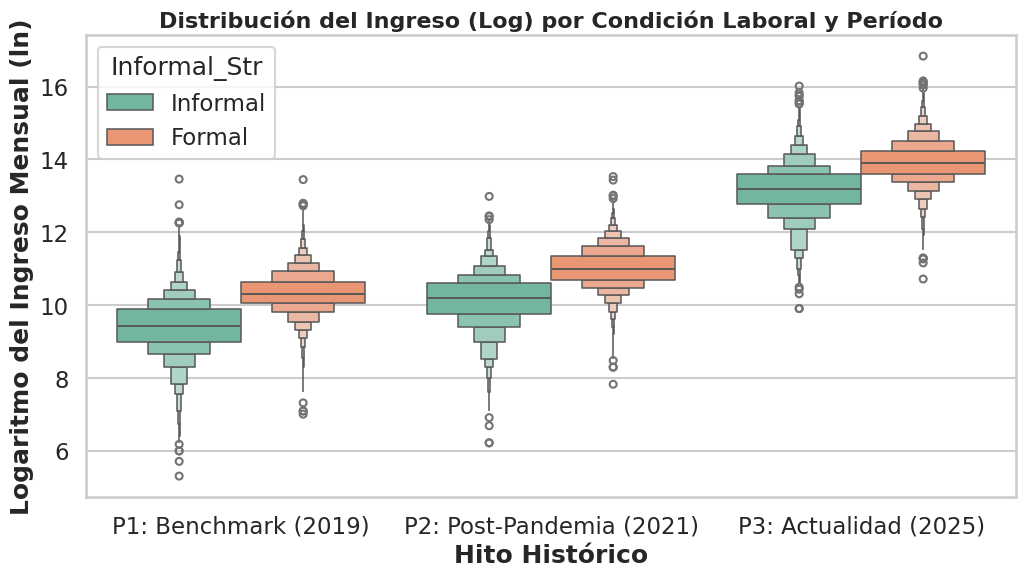


🔗 3. Matriz de Correlación de Spearman


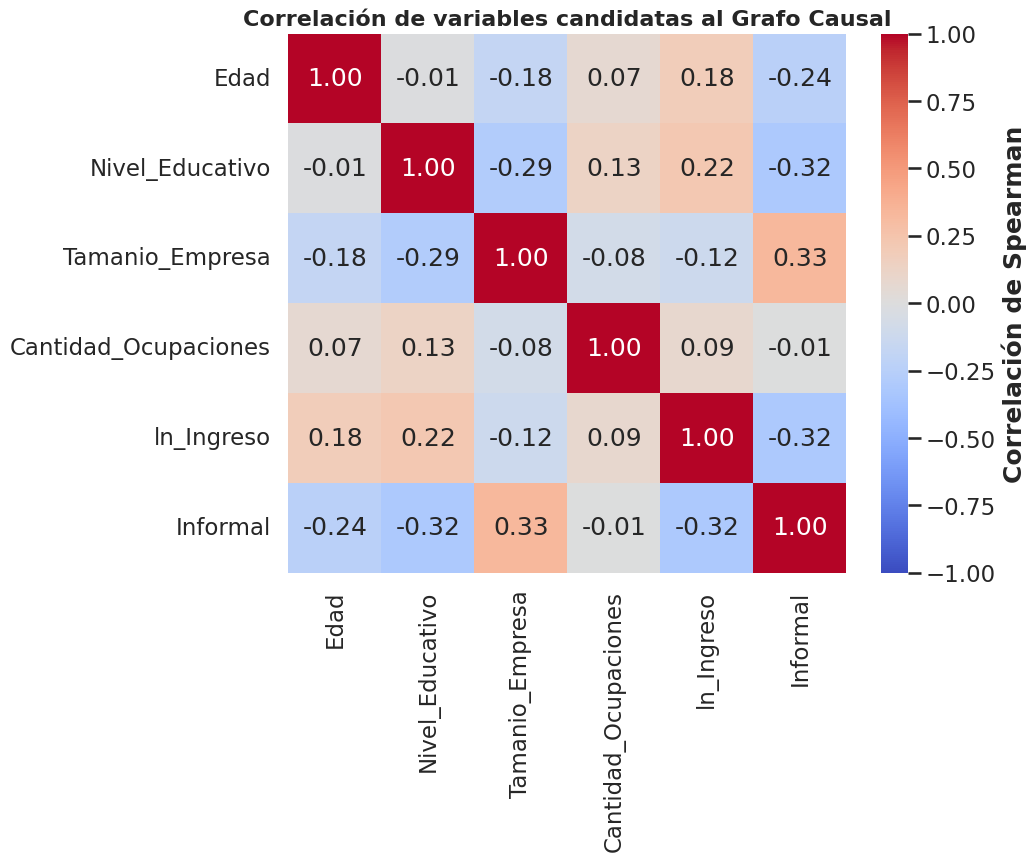


📈 4. Trayectorias Estructurales: Educación y Estrategia de Supervivencia (Pluriempleo)


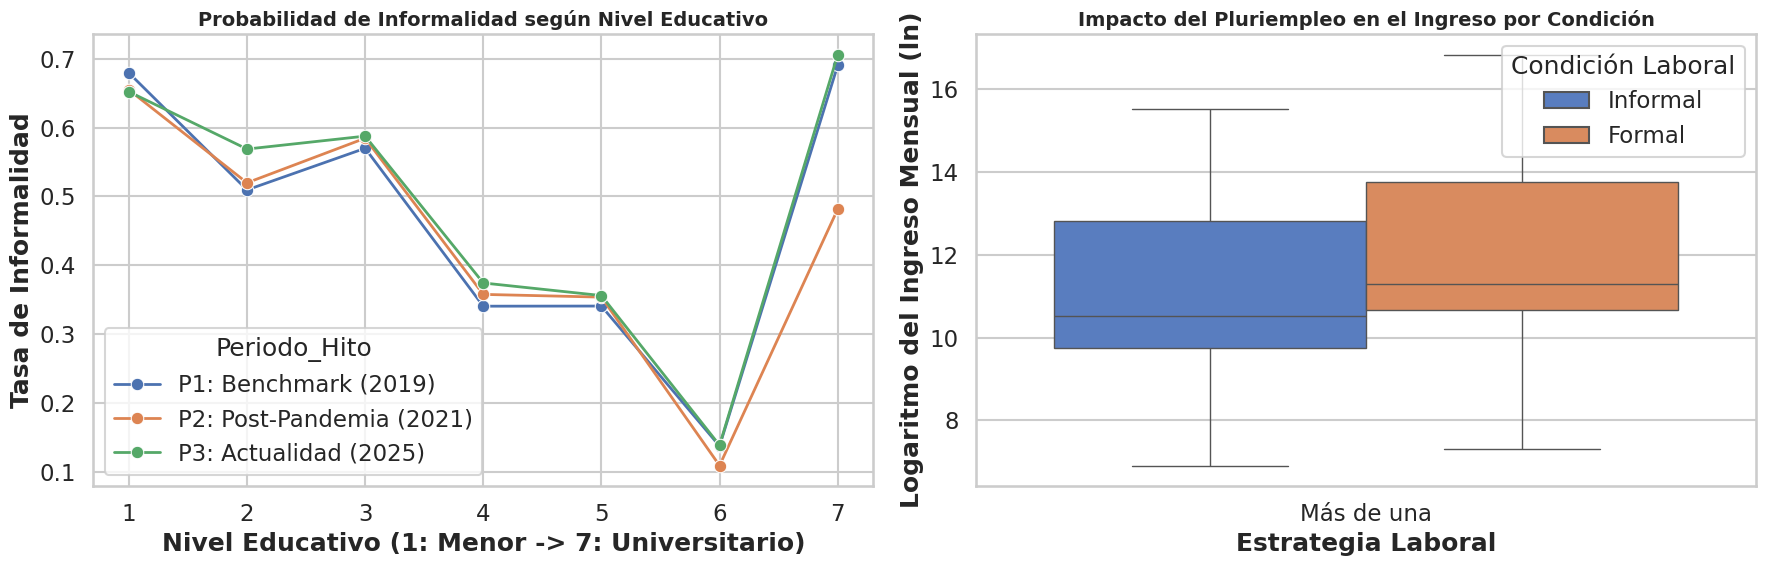

In [ ]:
# Configuración visual para gráficos con calidad académica
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 8)

# Asumimos que df_t ya pasó por el rename() y usamos esa versión
df_eda = df_t.copy()

# ---------------------------------------------------------
# PRE-PROCESAMIENTO RÁPIDO PARA EL EDA
# ---------------------------------------------------------
# 1. Transformación Logarítmica del Ingreso
df_eda['ln_Ingreso'] = np.log1p(pd.to_numeric(df_eda['Ingreso_Mensual_Pesos'], errors='coerce'))

# 2. Mapeo de variables para mejor lectura en gráficos (usando los nuevos nombres)
df_eda['Genero_Str'] = df_eda['Sexo'].map({1: 'Varón', 2: 'Mujer'})
df_eda['Informal_Str'] = df_eda['Informal'].map({0: 'Formal', 1: 'Informal'})
df_eda['Pluriempleo_Str'] = df_eda['Cantidad_Ocupaciones'].map({1: 'Una ocupación', 2: 'Más de una'})

# =========================================================
# 1. CALIDAD DE DATOS: TABLA DE VALORES FALTANTES
# =========================================================
print("🔍 1. Analizando Calidad de Datos (Valores Faltantes)")

# Usamos los nombres descriptivos
variables_tesis = [
    'Sexo', 'Edad', 'Estado_Civil', 'Nivel_Educativo', 'Region',
    'Tamanio_Empresa', 'Cantidad_Ocupaciones', 'Rama_Actividad_CAES',
    'Ingreso_Mensual_Pesos', 'Informal', 'ln_Ingreso'
]

# Cálculo de nulos y porcentajes
nulos_totales = df_eda[variables_tesis].isnull().sum()
nulos_porcentaje = (nulos_totales / len(df_eda)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos_totales,
    'Porcentaje (%)': nulos_porcentaje
}).sort_values(by='Porcentaje (%)', ascending=False)

print("\nTabla de Datos Faltantes (Ordenada por criticidad):")
display(tabla_nulos.style.format({'Porcentaje (%)': "{:.2f}%"}))

# Sesgo de no-respuesta cruzado con la informalidad
missing_income = df_eda.copy()
missing_income['Oculta_Ingreso'] = missing_income['Ingreso_Mensual_Pesos'].isna()
sesgo_ingreso = missing_income.groupby(['Periodo_Hito', 'Informal_Str'])['Oculta_Ingreso'].mean().unstack()
print("\nPorcentaje de asalariados que no declaran ingresos (Sesgo de No-Respuesta):")
display(sesgo_ingreso.style.format("{:.1%}"))

# =========================================================
# 2. DISTRIBUCIONES Y "SALTOS" NO LINEALES
# =========================================================
print("\n📊 2. Analizando Distribuciones y No Linealidad")

# A. Densidad de Edad vs Informalidad
g = sns.FacetGrid(df_eda, col="Periodo_Hito", hue="Informal_Str", height=5, aspect=1.2, palette="Set1")
g.map(sns.kdeplot, "Edad", fill=True, alpha=0.5)
g.add_legend(title="Condición")
g.fig.suptitle("Distribución de Edad según Condición Laboral por Período", y=1.05, fontsize=16)
plt.show()

# B. Distribución del Ingreso
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_eda.dropna(subset=['ln_Ingreso']),
              x="Periodo_Hito", y="ln_Ingreso", hue="Informal_Str", palette="Set2")
plt.title("Distribución del Ingreso (Log) por Condición Laboral y Período", fontsize=16)
plt.ylabel("Logaritmo del Ingreso Mensual (ln)")
plt.xlabel("Hito Histórico")
plt.show()

# =========================================================
# 3. ANÁLISIS DE CORRELACIONES (PRE-DAG)
# =========================================================
print("\n🔗 3. Matriz de Correlación de Spearman")

# Variables ordinales y numéricas para la matriz
vars_modelo = ['Edad', 'Nivel_Educativo', 'Tamanio_Empresa', 'Cantidad_Ocupaciones', 'ln_Ingreso', 'Informal']
df_corr = df_eda[vars_modelo].dropna()

corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlación de Spearman'})
plt.title("Correlación de variables candidatas al Grafo Causal", fontsize=16)
plt.show()

# =========================================================
# 4. ANÁLISIS COMPARATIVO ESTRUCTURAL
# =========================================================
print("\n📈 4. Trayectorias Estructurales: Educación y Estrategia de Supervivencia (Pluriempleo)")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico A: Brecha de Informalidad por Nivel Educativo
tasa_edu = df_eda.groupby(['Periodo_Hito', 'Nivel_Educativo'])['Informal'].mean().reset_index()
sns.lineplot(data=tasa_edu, x='Nivel_Educativo', y='Informal', hue='Periodo_Hito', marker='o', lw=2, ax=axes[0])
axes[0].set_title("Probabilidad de Informalidad según Nivel Educativo", fontsize=14)
axes[0].set_ylabel("Tasa de Informalidad")
axes[0].set_xlabel("Nivel Educativo (1: Menor -> 7: Universitario)")

# Gráfico B (NUEVO ENFOQUE): El impacto del pluriempleo en los ingresos
sns.boxplot(data=df_eda.dropna(subset=['ln_Ingreso']),
            x='Pluriempleo_Str', y='ln_Ingreso', hue='Informal_Str',
            palette="muted", ax=axes[1])
axes[1].set_title("Impacto del Pluriempleo en el Ingreso por Condición", fontsize=14)
axes[1].set_ylabel("Logaritmo del Ingreso Mensual (ln)")
axes[1].set_xlabel("Estrategia Laboral")
axes[1].legend(title="Condición Laboral")

plt.tight_layout()
plt.show()

PROBABILIDAD DE INFORMALIDAD POR NIVEL EDUCATIVO



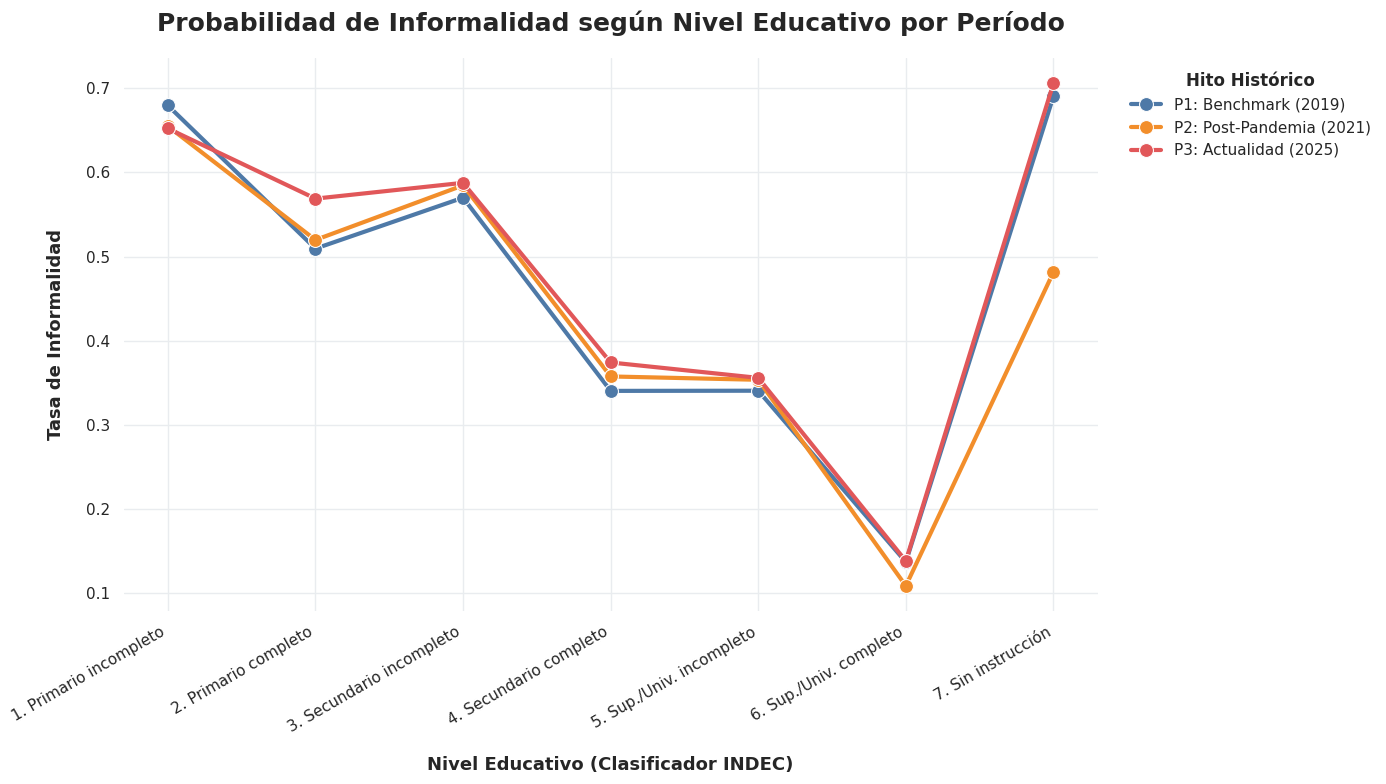


🔹 Tasa de Informalidad (%) por Nivel y Período:


Periodo_Hito,P1: Benchmark (2019),P2: Post-Pandemia (2021),P3: Actualidad (2025)
Nivel_Ed_Label,,,
1. Primario incompleto,67.97%,65.5%,65.23%
2. Primario completo,50.95%,51.98%,56.89%
3. Secundario incompleto,57.0%,58.47%,58.77%
4. Secundario completo,34.04%,35.76%,37.42%
5. Sup./Univ. incompleto,34.06%,35.36%,35.59%
6. Sup./Univ. completo,13.7%,10.87%,13.82%
7. Sin instrucción,69.05%,48.15%,70.59%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("PROBABILIDAD DE INFORMALIDAD POR NIVEL EDUCATIVO")
print("==================================================\n")

# 1. CONFIGURACIÓN ESTÉTICA
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", "grid.color": "#e9ecef"})
colores_periodos = ["#4E79A7", "#F28E2B", "#E15759"]

# 2. MAPEO OFICIAL INDEC (Corregido)
mapa_educacion = {
    1: '1. Primario incompleto',
    2: '2. Primario completo',
    3: '3. Secundario incompleto',
    4: '4. Secundario completo',
    5: '5. Sup./Univ. incompleto',
    6: '6. Sup./Univ. completo',
    7: '7. Sin instrucción'
}

# 3. PREPARACIÓN DE DATOS
# Creamos la columna con etiquetas reales
df_eda['Nivel_Ed_Label'] = df_eda['Nivel_Educativo'].map(mapa_educacion)

# Calculamos la tasa
tasa_edu = df_eda.groupby(['Periodo_Hito', 'Nivel_Educativo', 'Nivel_Ed_Label'])['Informal'].mean().reset_index()

# 4. CREACIÓN DEL GRÁFICO
plt.figure(figsize=(14, 8))

# Usamos Nivel_Educativo (numérico) para el eje X para que la línea sea continua,
# pero luego cambiaremos los "ticks" por las etiquetas reales.
ax = sns.lineplot(
    data=tasa_edu,
    x='Nivel_Educativo',
    y='Informal',
    hue='Periodo_Hito',
    marker='o',
    markersize=10,
    lw=3,
    palette=colores_periodos
)

# 5. AJUSTE DE ETIQUETAS REALES EN EJE X
# Seteamos los valores del 1 al 7 y les asignamos sus nombres correspondientes
plt.xticks(
    ticks=range(1, 8),
    labels=[mapa_educacion[i] for i in range(1, 8)],
    rotation=30,
    ha='right'
)

# 6. DETALLES FINALES
plt.title("Probabilidad de Informalidad según Nivel Educativo por Período", fontsize=18, pad=20)
plt.ylabel("Tasa de Informalidad", fontsize=13, labelpad=15)
plt.xlabel("Nivel Educativo (Clasificador INDEC)", fontsize=13, labelpad=15)

plt.legend(
    title="Hito Histórico",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title_fontproperties={'weight': 'bold'}
)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Resumen numérico para validar
print("\n🔹 Tasa de Informalidad (%) por Nivel y Período:")
tabla_resumen = tasa_edu.pivot(index='Nivel_Ed_Label', columns='Periodo_Hito', values='Informal')
display((tabla_resumen * 100).round(2).astype(str) + '%')

MATRIZ DE CORRELACIÓN (SPEARMAN)



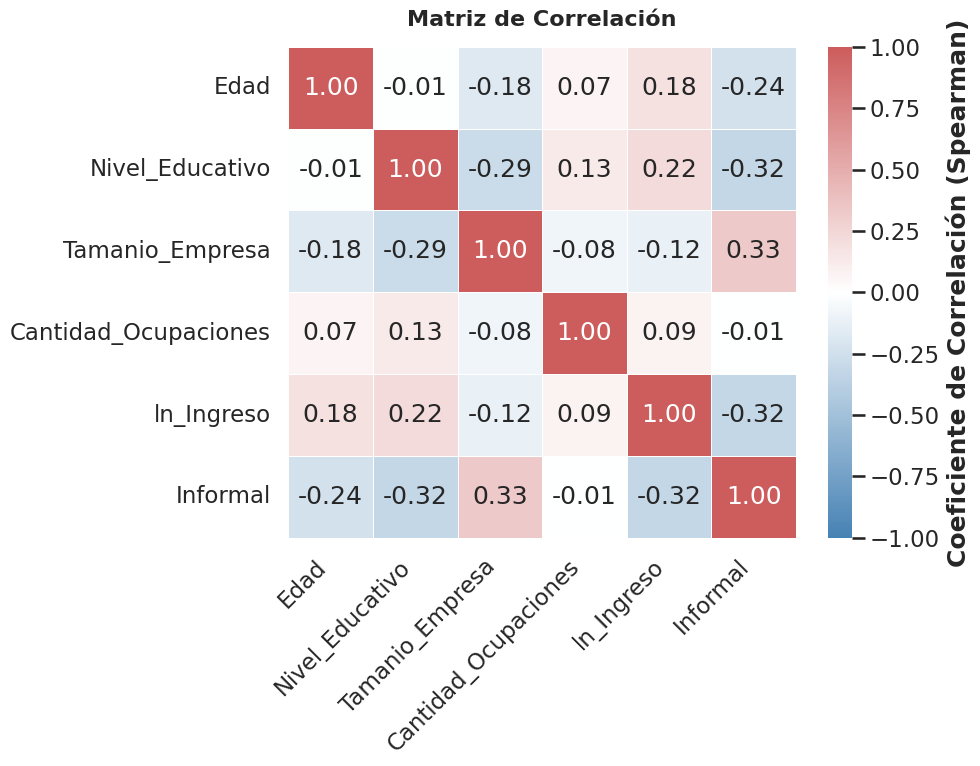

In [ ]:

from matplotlib.colors import LinearSegmentedColormap

# Configuración visual básica
sns.set_theme(style="whitegrid", context="talk")

# 1. Preparación de los datos (asumiendo que df_t ya está en memoria)
df_eda = df_t.copy()
df_eda['ln_Ingreso'] = np.log1p(pd.to_numeric(df_eda['Ingreso_Mensual_Pesos'], errors='coerce'))

print("==================================================")
print("MATRIZ DE CORRELACIÓN (SPEARMAN)")
print("==================================================\n")

# 2. Selección de variables para la matriz
vars_modelo = ['Edad', 'Nivel_Educativo', 'Tamanio_Empresa', 'Cantidad_Ocupaciones', 'ln_Ingreso', 'Informal']
df_corr = df_eda[vars_modelo].dropna()

# 3. Cálculo de la correlación (Spearman es ideal para capturar relaciones ordinales y no lineales)
corr_matrix = df_corr.corr(method='spearman')

# 4. Creación del mapa de colores personalizado (Steelblue -> Blanco -> Indianred)
cmap_personalizado = LinearSegmentedColormap.from_list(
    "steel_to_indian", ["steelblue", "white", "indianred"]
)

# 5. Visualización del Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,               # Muestra los números
    cmap=cmap_personalizado,  # Aplica la paleta solicitada
    fmt=".2f",                # Formato a 2 decimales
    vmin=-1,                  # Límite inferior (-1 correlación negativa perfecta)
    vmax=1,                   # Límite superior (1 correlación positiva perfecta)
    linewidths=.5,            # Agrega líneas separadoras entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)

plt.title("Matriz de Correlación", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right') # Rota las etiquetas del eje X para mejor lectura
plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIÓN (VARIABLES FILTRADAS)



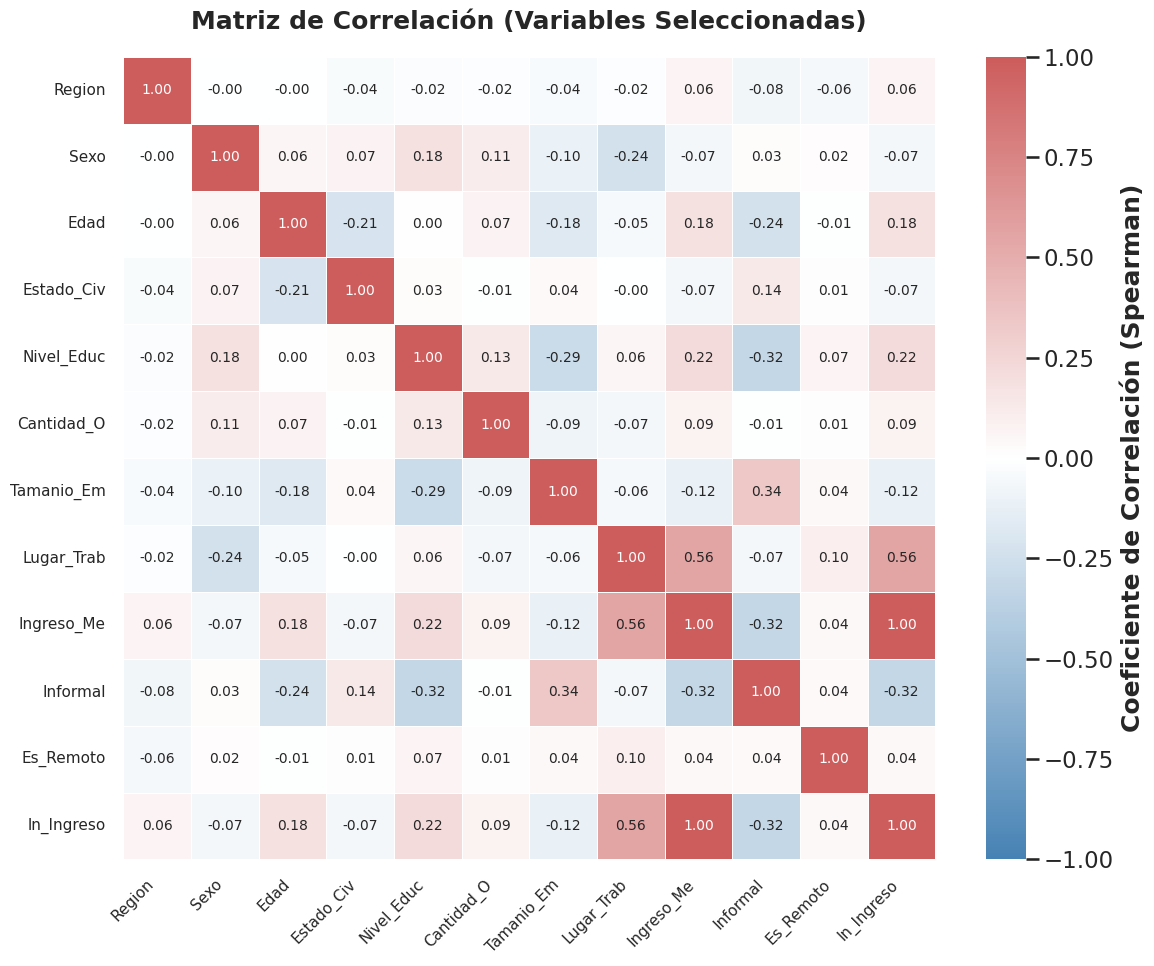

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Configuración visual básica
sns.set_theme(style="whitegrid", context="talk")

# 1. Preparación de los datos
df_eda = df_t.copy()

if 'Ingreso_Mensual_Pesos' in df_eda.columns:
    df_eda['ln_Ingreso'] = np.log1p(pd.to_numeric(df_eda['Ingreso_Mensual_Pesos'], errors='coerce'))

print("==================================================")
print("MATRIZ DE CORRELACIÓN (VARIABLES FILTRADAS)")
print("==================================================\n")

# 2. Definición de variables a excluir
cols_excluir_fijas = [
    'ID_Hogar', 'ID_Persona', 'Trimestre', 'Anio',
    'Condicion_Actividad', 'Categoria_Ocupacional',
    'Descuento_Jubilatorio', 'Rama_Actividad_CAES'
]

# Identificamos todas las columnas que terminan en '_Str'
cols_str = [col for col in df_eda.columns if str(col).endswith('_Str')]

# Unimos ambas listas
todas_cols_a_excluir = cols_excluir_fijas + cols_str

# 3. Selección y filtrado del DataFrame
# Nos quedamos con numéricas y booleanas
df_numerico = df_eda.select_dtypes(include=['number', 'bool'])

# Eliminamos las columnas no deseadas (verificando que existan para evitar errores)
cols_a_dropear = [col for col in todas_cols_a_excluir if col in df_numerico.columns]
df_filtrado = df_numerico.drop(columns=cols_a_dropear)

# 4. Cálculo de la correlación de Spearman
corr_matrix = df_filtrado.corr(method='spearman')

# 5. Truncar los nombres de las variables a un máximo de 10 caracteres
nombres_truncados = [str(col)[:10] for col in corr_matrix.columns]
corr_matrix.columns = nombres_truncados
corr_matrix.index = nombres_truncados

# 6. Creación del mapa de colores personalizado (Steelblue -> Blanco -> Indianred)
cmap_personalizado = LinearSegmentedColormap.from_list(
    "steel_to_indian", ["steelblue", "white", "indianred"]
)

# 7. Visualización del Heatmap
# Ajustamos un poco el tamaño de la figura al tener menos variables
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap_personalizado,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=.5,
    annot_kws={"size": 10},   # Volvemos a agrandar un poco la fuente de los números
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)

plt.title("Matriz de Correlación (Variables Seleccionadas)", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIÓN SPEARMAN (SOLO VARS. VÁLIDAS)



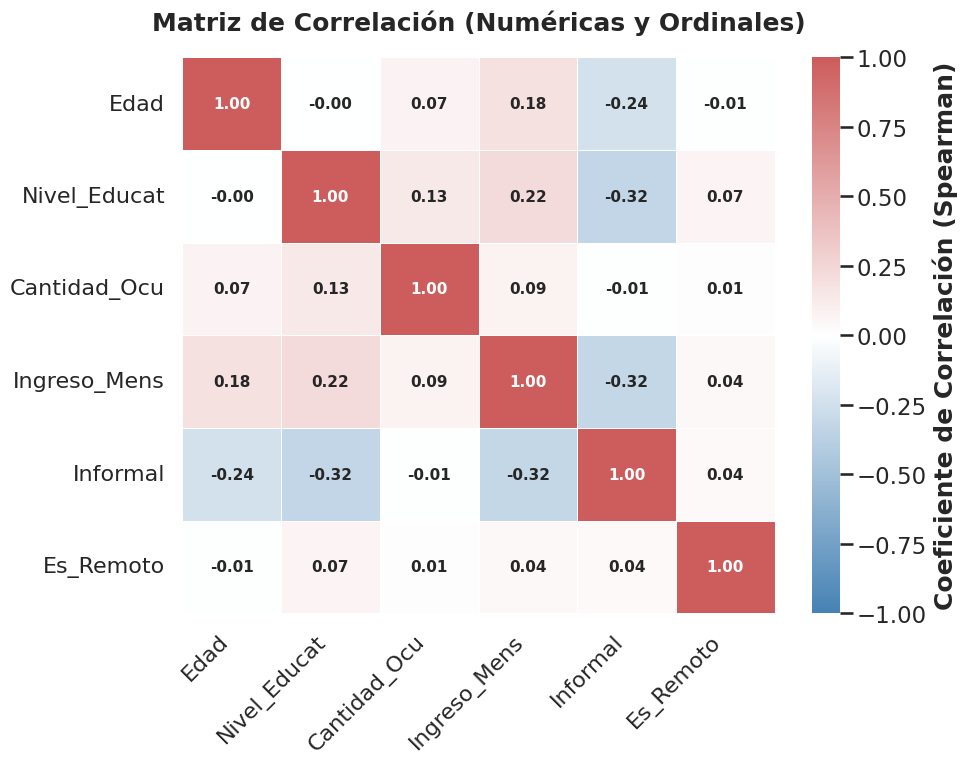

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Configuración visual básica
sns.set_theme(style="whitegrid", context="talk")

# 1. Preparación de los datos
df_eda = df_t.copy()

if 'Ingreso_Mensual_Pesos' in df_eda.columns:
    df_eda['ln_Ingreso'] = np.log1p(pd.to_numeric(df_eda['Ingreso_Mensual_Pesos'], errors='coerce'))

print("==================================================")
print("MATRIZ DE CORRELACIÓN SPEARMAN (SOLO VARS. VÁLIDAS)")
print("==================================================\n")

# 2. Corrección ordinal de Nivel Educativo
# INDEC usa 7 para "Sin Instrucción". Para Spearman, debemos pasarlo a 0 para no romper la monotonía.
if 'Nivel_Educativo' in df_eda.columns:
    df_eda['Nivel_Educativo_Ord'] = df_eda['Nivel_Educativo'].replace(7, 0)

# 3. Definición ESTRICTA de variables válidas (Lista Blanca)
# Dejamos afuera nominales como Region, Sexo, Estado_Civil, Tamanio_Empresa y Lugar_Trabajo
vars_validas = [
    'Edad',
    'Nivel_Educativo_Ord',
    'Cantidad_Ocupaciones',
    'Ingreso_Mensual_Pesos',
    'Informal',
    'Es_Remoto'
]

# Filtramos el DataFrame asegurándonos de que las columnas existan
cols_a_usar = [col for col in vars_validas if col in df_eda.columns]
df_filtrado = df_eda[cols_a_usar]

# 4. Cálculo de la correlación de Spearman
corr_matrix = df_filtrado.corr(method='spearman')

# 5. Truncar/Acomodar los nombres de las variables a un máximo de 12 caracteres para prolijidad
nombres_truncados = [str(col).replace('_Ord', '')[:12] for col in corr_matrix.columns]
corr_matrix.columns = nombres_truncados
corr_matrix.index = nombres_truncados

# 6. Creación del mapa de colores personalizado (Steelblue -> Blanco -> Indianred)
cmap_personalizado = LinearSegmentedColormap.from_list(
    "steel_to_indian", ["steelblue", "white", "indianred"]
)

# 7. Visualización del Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap_personalizado,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=.5,
    annot_kws={"size": 11, "fontweight": "bold"}, # Números claros y en negrita
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)

plt.title("Matriz de Correlación (Numéricas y Ordinales)", fontsize=18, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

ANÁLISIS DE VARIANZA: RAZÓN DE CORRELACIÓN (ETA)



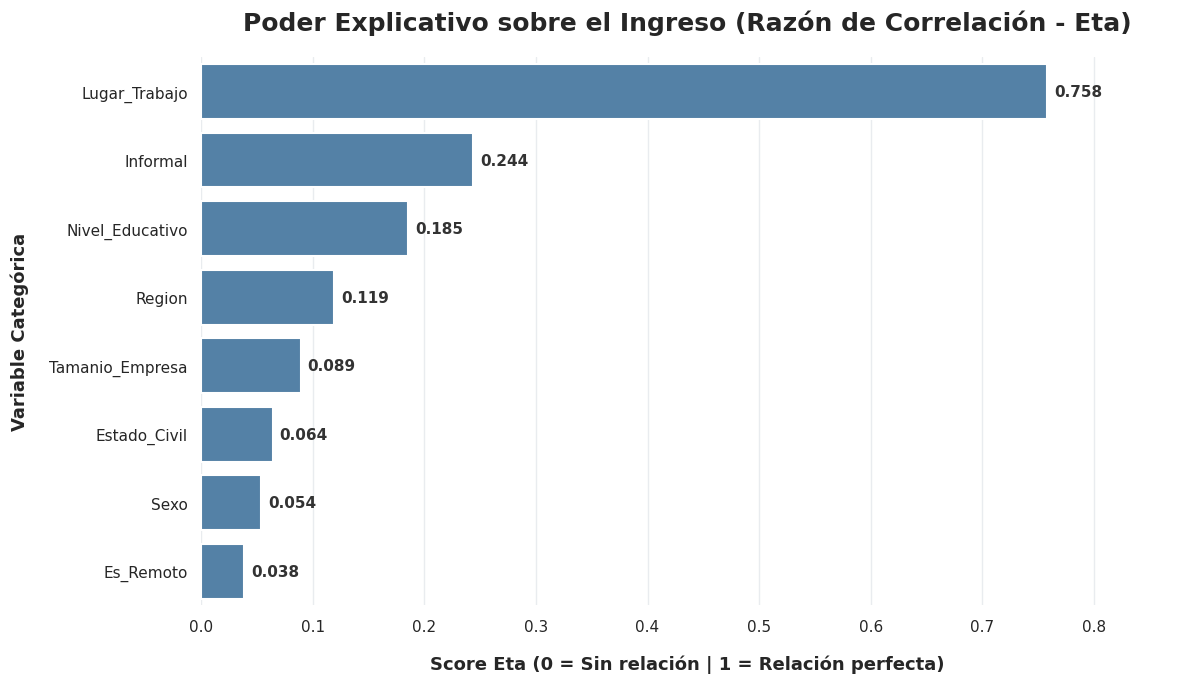


🔹 Ranking de variables que más impactan en la varianza del Ingreso:


,Eta_Score
Variable,
Lugar_Trabajo,0.758
Informal,0.244
Nivel_Educativo,0.185
Region,0.119
Tamanio_Empresa,0.089
Estado_Civil,0.064
Sexo,0.054
Es_Remoto,0.038


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("ANÁLISIS DE VARIANZA: RAZÓN DE CORRELACIÓN (ETA)")
print("==================================================\n")

# 1. Función para calcular la Razón de Correlación (Eta)
def correlation_ratio(categories, measurements):
    """
    Calcula la Razón de Correlación (Eta) entre una variable categórica y una numérica continua.
    Retorna un valor entre 0 y 1.
    """
    # Armamos un dataframe temporal y limpiamos nulos para este cruce
    df_temp = pd.DataFrame({'cat': categories, 'val': measurements}).dropna()

    if df_temp.empty:
        return np.nan

    y_mean = df_temp['val'].mean()

    # Suma de Cuadrados Total (Varianza total del ingreso)
    sst = ((df_temp['val'] - y_mean)**2).sum()

    # Suma de Cuadrados Entre Grupos (Varianza explicada por la categoría)
    promedios_grupo = df_temp.groupby('cat')['val'].mean()
    tamanio_grupo = df_temp.groupby('cat').size()
    ssb = ((promedios_grupo - y_mean)**2 * tamanio_grupo).sum()

    if sst == 0:
        return 0.0

    # Eta es la raíz cuadrada de la proporción de varianza explicada
    return np.sqrt(ssb / sst)


# 2. Configuración Estética "Premium"
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", "grid.color": "#e9ecef"})

# 3. Definición de Variables
# Usamos el logaritmo del ingreso para que los outliers no distorsionen la varianza
target_num = df_eda['ln_Ingreso']

# Lista de variables categóricas nominales y ordinales a evaluar
vars_categoricas = [
    'Lugar_Trabajo', 'Region', 'Estado_Civil', 'Sexo',
    'Nivel_Educativo', 'Tamanio_Empresa',
    'Es_Remoto', 'Informal'
]

# 4. Cálculo iterativo para todas las variables
resultados_eta = {}

for col in vars_categoricas:
    if col in df_eda.columns:
        score_eta = correlation_ratio(df_eda[col], target_num)
        resultados_eta[col] = score_eta

# Convertimos a DataFrame y ordenamos de mayor a menor impacto
df_eta = pd.DataFrame(list(resultados_eta.items()), columns=['Variable', 'Eta_Score'])
df_eta = df_eta.sort_values(by='Eta_Score', ascending=False)

# 5. CREACIÓN DEL GRÁFICO
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

sns.barplot(
    data=df_eta,
    y='Variable',
    x='Eta_Score',
    color='steelblue',   # Tu color preferido
    edgecolor='white',
    linewidth=1.5,
    ax=ax
)

# 6. Etiquetas de datos sobre las barras
for container in ax.containers:
    # Mostramos el score formateado a 3 decimales
    labels = [f'{v:.3f}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold', color='#333333')

# Ajuste de ejes y títulos
ax.set_xlim(0, df_eta['Eta_Score'].max() * 1.15) # Damos margen para que entren las etiquetas
ax.set_title("Poder Explicativo sobre el Ingreso (Razón de Correlación - Eta)", fontsize=18, pad=20)
ax.set_xlabel("Score Eta (0 = Sin relación | 1 = Relación perfecta)", fontsize=13, labelpad=15)
ax.set_ylabel("Variable Categórica", fontsize=13, labelpad=15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 7. REPORTE TABULADO
print("\n🔹 Ranking de variables que más impactan en la varianza del Ingreso:")
display(df_eta.set_index('Variable').style.format("{:.3f}"))

## Mapeo de diccionarios

In [ ]:
# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")

# Mapeos para que los gráficos sean descriptivos
map_estado_civil = {1: 'Unido', 2: 'Casado', 3: 'Separado/Div', 4: 'Viudo', 5: 'Soltero'}
map_region = {1: 'GBA', 40: 'NOA', 41: 'NEA', 42: 'Cuyo', 43: 'Pampeana', 44: 'Patagonia'}
map_tamanio = {1: '1 pers', 2: '2-5 pers', 3: '6-40 pers', 4: '41-100 pers', 5: '101-500 pers', 6: '>500 pers', 9: 'Ns/Nr'}
map_nivel_ed = {1: 'Prim Incomp', 2: 'Prim Comp', 3: 'Sec Incomp', 4: 'Sec Comp', 5: 'Sup Incomp', 6: 'Sup Comp', 7: 'Sin Instr'}

df_eda['Estado_Civil_Str'] = df_eda['Estado_Civil'].map(map_estado_civil)
df_eda['Region_Str'] = df_eda['Region'].map(map_region)
df_eda['Tamanio_Str'] = df_eda['Tamanio_Empresa'].map(map_tamanio)
df_eda['Nivel_Ed_Str'] = df_eda['Nivel_Educativo'].map(map_nivel_ed)

## Dimensión Demográfica

📊 DIMENSIÓN DEMOGRÁFICA


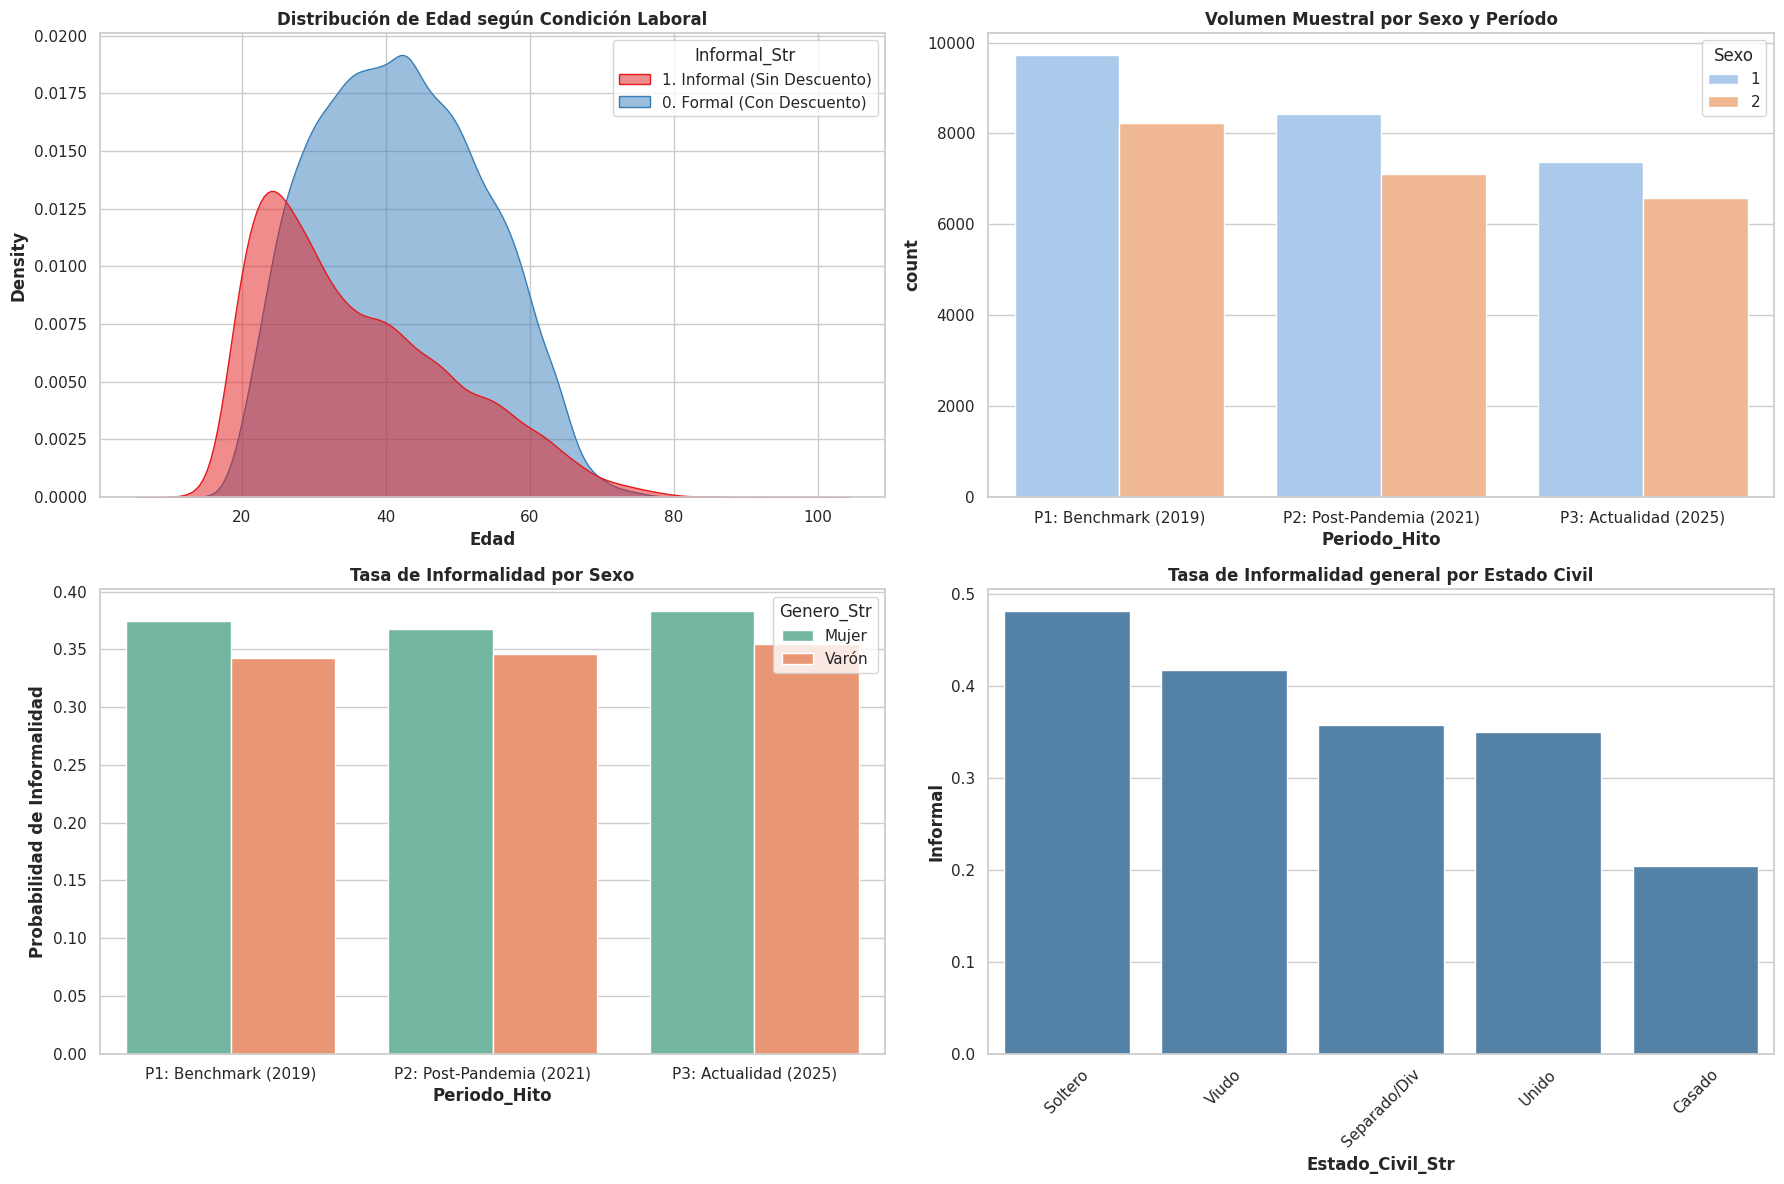

In [ ]:
# 1. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 2. Mapeos descriptivos
df_eda['Genero_Str'] = df_eda['Sexo'].map({1: 'Varón', 2: 'Mujer'})

mapa_informal = {
    0: '0. Formal (Con Descuento)',
    1: '1. Informal (Sin Descuento)'
}
df_eda['Informal_Str'] = df_eda['Informal'].map(mapa_informal).fillna('Sin Dato / NR')


print("📊 DIMENSIÓN DEMOGRÁFICA")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Edad vs Informalidad (El que queríamos conservar)
sns.kdeplot(data=df_eda, x="Edad", hue="Informal_Str", fill=True, alpha=0.5, ax=axes[0,0], palette="Set1")
axes[0,0].set_title("Distribución de Edad según Condición Laboral")

# 2. Sexo vs Informalidad por Período
# Usamos countplot para ver el volumen real
sns.countplot(data=df_eda, x="Periodo_Hito", hue="Sexo", palette="pastel", ax=axes[0,1])
axes[0,1].set_title("Volumen Muestral por Sexo y Período")

# 3. Informalidad dentro de cada sexo (Tasa)
tasa_sexo = df_eda.groupby(['Periodo_Hito', 'Genero_Str'])['Informal'].mean().reset_index()
sns.barplot(data=tasa_sexo, x='Periodo_Hito', y='Informal', hue='Genero_Str', palette="Set2", ax=axes[1,0])
axes[1,0].set_title("Tasa de Informalidad por Sexo")
axes[1,0].set_ylabel("Probabilidad de Informalidad")

# 4. Estado Civil e Informalidad
tasa_civil = df_eda.groupby('Estado_Civil_Str')['Informal'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=tasa_civil, x='Estado_Civil_Str', y='Informal', color="steelblue", ax=axes[1,1])
axes[1,1].set_title("Tasa de Informalidad general por Estado Civil")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

TASA DE INFORMALIDAD POR SEXO Y PERÍODO



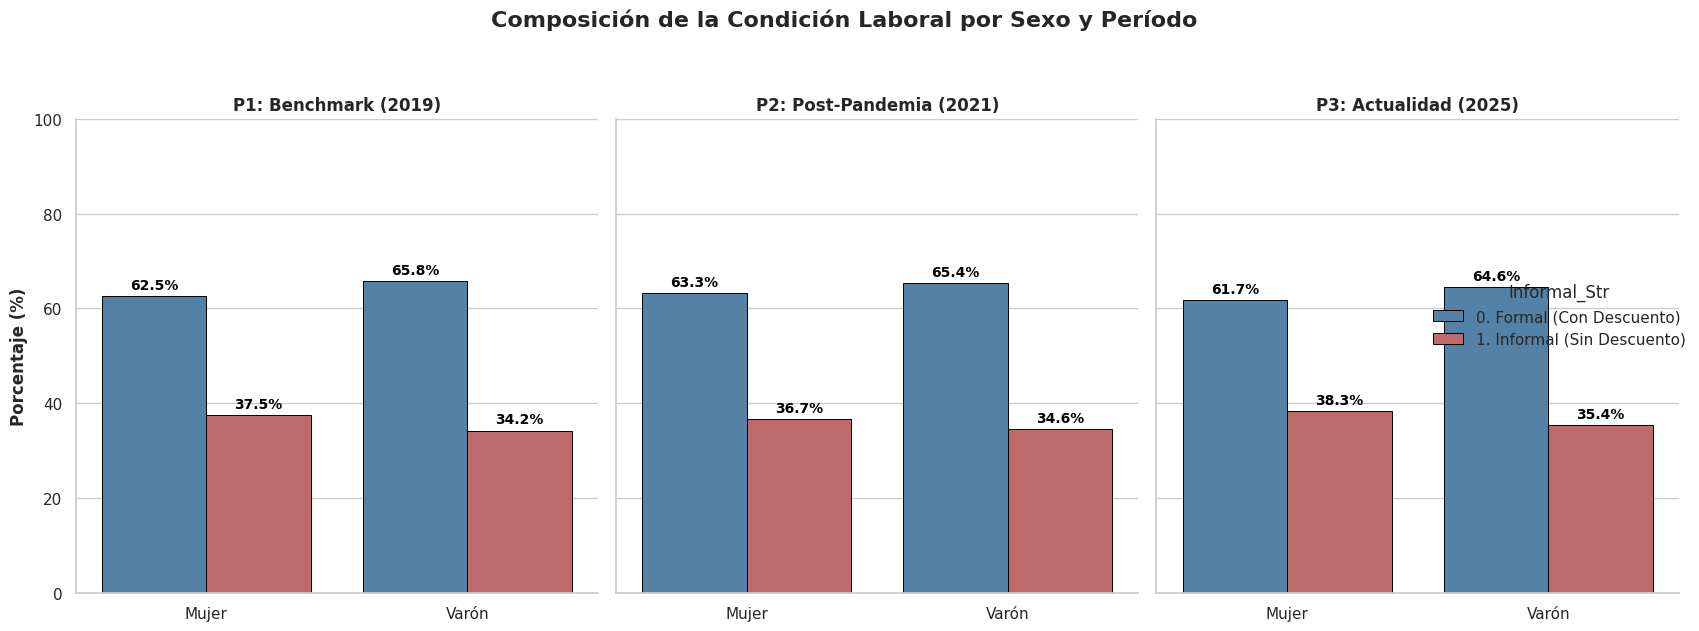


🔹 Resumen Tabulado (Tasa de Informalidad por Sexo):


Periodo_Hito,P1: Benchmark (2019),P2: Post-Pandemia (2021),P3: Actualidad (2025)
Genero_Str,,,
Mujer,37.5%,36.7%,38.3%
Varón,34.2%,34.6%,35.4%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("TASA DE INFORMALIDAD POR SEXO Y PERÍODO")
print("==================================================\n")

# 1. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 2. Mapeos descriptivos
df_eda['Genero_Str'] = df_eda['Sexo'].map({1: 'Varón', 2: 'Mujer'})

mapa_informal = {
    0: '0. Formal (Con Descuento)',
    1: '1. Informal (Sin Descuento)'
}
df_eda['Informal_Str'] = df_eda['Informal'].map(mapa_informal).fillna('Sin Dato / NR')

# 3. Calculamos los porcentajes relativos DENTRO de cada sexo
conteo = df_eda.groupby(['Periodo_Hito', 'Genero_Str', 'Informal_Str']).size().reset_index(name='Cantidad')
totales = df_eda.groupby(['Periodo_Hito', 'Genero_Str']).size().reset_index(name='Total_Sexo')

tasa_df = pd.merge(conteo, totales, on=['Periodo_Hito', 'Genero_Str'])
tasa_df['Porcentaje'] = (tasa_df['Cantidad'] / tasa_df['Total_Sexo']) * 100

# 4. Creación del gráfico
# Usamos catplot para generar un subgráfico por cada período automáticamente
g = sns.catplot(
    data=tasa_df,
    x='Genero_Str',
    y='Porcentaje',
    hue='Informal_Str',
    col='Periodo_Hito',
    kind='bar',
    palette=colores_informalidad,
    height=6,
    aspect=0.8,
    edgecolor='black',
    linewidth=0.7
)

# Ajustes estéticos
g.fig.suptitle("Composición de la Condición Laboral por Sexo y Período", fontsize=16, fontweight='bold', y=1.05)
g.set_axis_labels("", "Porcentaje (%)")
g.set_titles("{col_name}", size=12, weight='bold')

# Agregamos las etiquetas numéricas a cada barra
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, color='black', fontweight='bold')
    ax.set_ylim(0, 100) # Fijamos el eje Y para que los 3 gráficos mantengan la misma escala

plt.tight_layout()
plt.show()

# 5. Reporte Tabulado
print("\n🔹 Resumen Tabulado (Tasa de Informalidad por Sexo):")
# Filtramos solo la categoría de informalidad para mostrar la métrica directa
tasa_informalidad = tasa_df[tasa_df['Informal_Str'] == '1. Informal (Sin Descuento)'].pivot(
    index='Genero_Str',
    columns='Periodo_Hito',
    values='Porcentaje'
)
display(tasa_informalidad.round(1).astype(str) + '%')

## Dimensión de Capital Humano y Geografía

📚 DIMENSIÓN DE CAPITAL HUMANO Y TERRITORIO


/tmp/ipykernel_28479/1484535421.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(orden_edu, rotation=45)


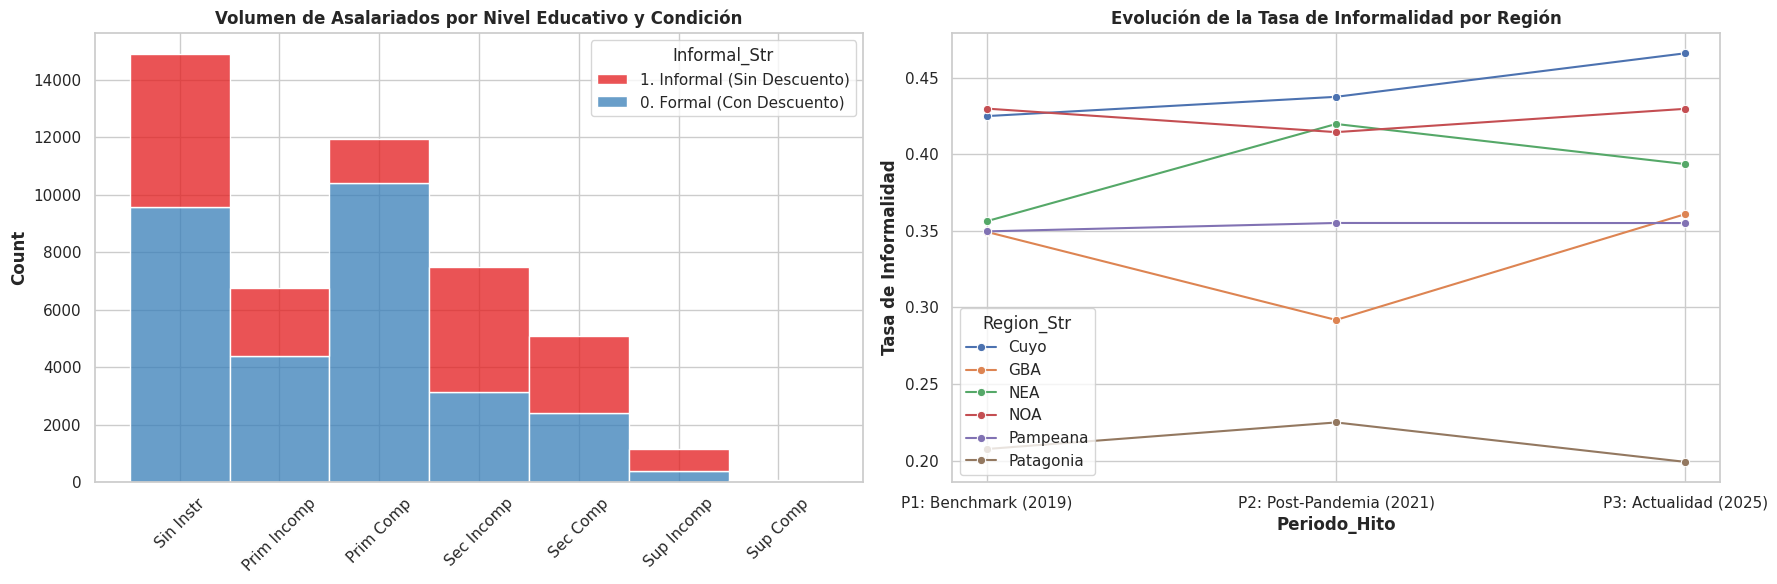

In [ ]:
print("📚 DIMENSIÓN DE CAPITAL HUMANO Y TERRITORIO")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribución por Nivel Educativo (Ordenado lógicamente)
orden_edu = ['Sin Instr', 'Prim Incomp', 'Prim Comp', 'Sec Incomp', 'Sec Comp', 'Sup Incomp', 'Sup Comp']
sns.histplot(data=df_eda, x='Nivel_Ed_Str', hue='Informal_Str', multiple="stack",
             palette="Set1", ax=axes[0])
axes[0].set_title("Volumen de Asalariados por Nivel Educativo y Condición")
axes[0].set_xticklabels(orden_edu, rotation=45)
axes[0].set_xlabel("")

# 2. Distribución por Región e Informalidad
tasa_region = df_eda.groupby(['Periodo_Hito', 'Region_Str'])['Informal'].mean().reset_index()
sns.lineplot(data=tasa_region, x='Periodo_Hito', y='Informal', hue='Region_Str', marker='o', ax=axes[1])
axes[1].set_title("Evolución de la Tasa de Informalidad por Región")
axes[1].set_ylabel("Tasa de Informalidad")

plt.tight_layout()
plt.show()

EVOLUCIÓN DE LA TASA DE INFORMALIDAD POR REGIÓN



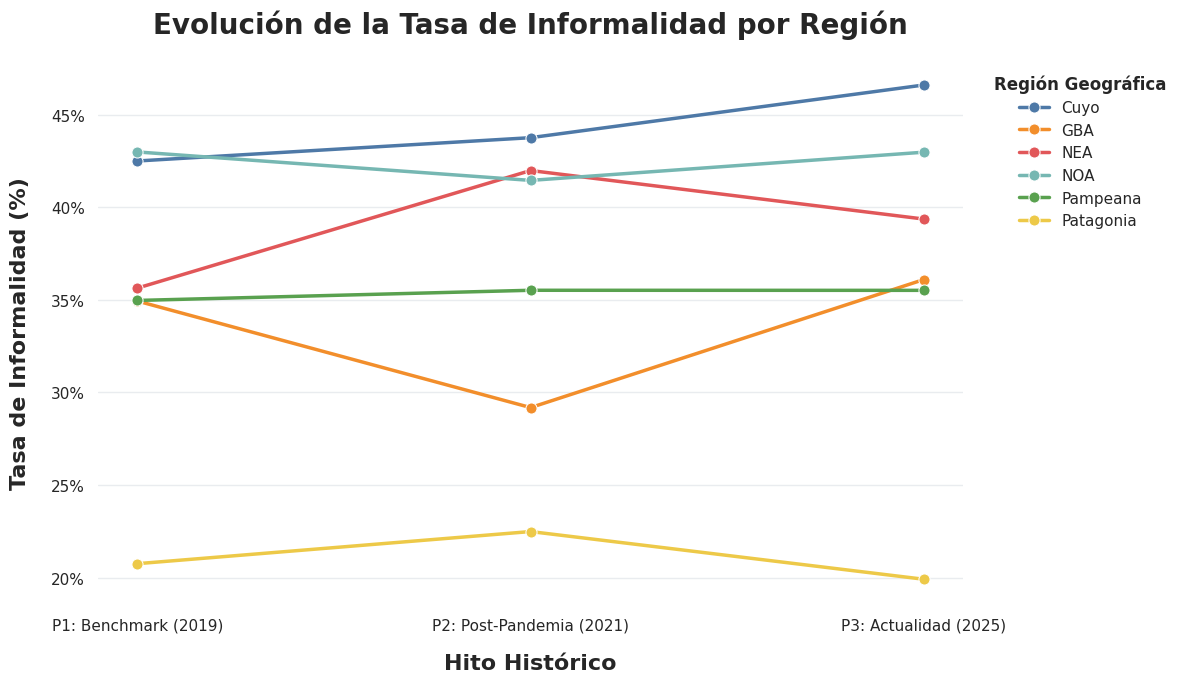


🔹 Resumen Tabulado (Tasa de Informalidad por Región):


Periodo_Hito,P1: Benchmark (2019),P2: Post-Pandemia (2021),P3: Actualidad (2025)
Region_Str,,,
Cuyo,42.5%,43.8%,46.6%
GBA,34.9%,29.2%,36.1%
NEA,35.6%,42.0%,39.4%
NOA,43.0%,41.5%,43.0%
Pampeana,35.0%,35.5%,35.5%
Patagonia,20.8%,22.5%,19.9%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

print("==================================================")
print("EVOLUCIÓN DE LA TASA DE INFORMALIDAD POR REGIÓN")
print("==================================================\n")

# 1. CONFIGURACIÓN ESTÉTICA "PREMIUM"
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Fondo blanco con grilla horizontal sutil (ideal para gráficos de líneas)
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", "grid.color": "#e9ecef"})

# Paleta profesional de 6 colores para las 6 regiones del INDEC
colores_regiones = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948"]

# 2. CÁLCULO DE LA TASA DE INFORMALIDAD
# Calculamos la media y la multiplicamos por 100 para tener el porcentaje directo
tasa_region = df_eda.groupby(['Periodo_Hito', 'Region_Str'])['Informal'].mean().reset_index()
tasa_region['Informal_Pct'] = tasa_region['Informal'] * 100

# 3. CREACIÓN DEL GRÁFICO
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

sns.lineplot(
    data=tasa_region,
    x='Periodo_Hito',
    y='Informal_Pct',
    hue='Region_Str',
    marker='o',          # Agrega los puntos en cada año
    markersize=8,        # Tamaño de los puntos
    linewidth=2.5,       # Grosor de las líneas
    palette=colores_regiones,
    ax=ax
)

# 4. DETALLES ESTÉTICOS Y LEYENDA
ax.set_title("Evolución de la Tasa de Informalidad por Región", fontsize=20, pad=20)
ax.set_ylabel("Tasa de Informalidad (%)", fontsize=16, labelpad=15)
ax.set_xlabel("Hito Histórico", fontsize=16, labelpad=15)

# Formateo del eje Y para que muestre el símbolo de porcentaje
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Ajuste de la leyenda (fuera del gráfico para no tapar las líneas)
ax.legend(
    title="Región Geográfica",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    title_fontproperties={'weight': 'bold'}
)

# Limpieza visual
sns.despine(left=True, bottom=True)
ax.xaxis.grid(False) # Apagamos la grilla vertical para un look más limpio

plt.tight_layout()
plt.show()

# 5. REPORTE TABULADO
print("\n🔹 Resumen Tabulado (Tasa de Informalidad por Región):")
tabla_region = tasa_region.pivot(index='Region_Str', columns='Periodo_Hito', values='Informal_Pct')
display(tabla_region.round(1).astype(str) + '%')

## Analítico de Ingresos

In [ ]:
print("💰 DEEP DIVE: DISTRIBUCIÓN DE INGRESOS")
# Filtramos nulos en ingresos para no romper los gráficos
df_ingresos = df_eda.dropna(subset=['Ingreso_Mensual_Pesos', 'ln_Ingreso']).copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# 1. Ingreso Promedio Nominal (OJO: Distorsionado por inflación)
promedio_ing = df_ingresos.groupby(['Periodo_Hito', 'Informal_Str'])['Ingreso_Mensual_Pesos'].mean().reset_index()
sns.barplot(data=promedio_ing, x='Periodo_Hito', y='Ingreso_Mensual_Pesos', hue='Informal_Str', palette="Set2", ax=axes[0])
axes[0].set_title("Ingreso Mensual Promedio (Valores Nominales - Afectado por Inflación)")
axes[0].set_ylabel("Pesos AR$")

# 2. Análisis de Outliers Reales (Escala logarítmica para poder ver los 3 periodos juntos)
# Si lo hacemos en pesos nominales, los outliers del 2025 aplastan la visualización del 2019.
sns.boxplot(data=df_ingresos, x='Periodo_Hito', y='ln_Ingreso', hue='Informal_Str', palette="pastel", ax=axes[1])
axes[1].set_title("Análisis de Outliers y Dispersión (Escala Logarítmica)")
axes[1].set_ylabel("$ln(Ingreso)$")

# 3. Forma y Sesgo de la Distribución: Violin Plot
sns.violinplot(data=df_ingresos, x='Periodo_Hito', y='ln_Ingreso', hue='Informal_Str',
               split=True, inner="quart", palette="Set1", ax=axes[2])
axes[2].set_title("Violin Plot: Densidad y Sesgo de la Distribución del Ingreso")
axes[2].set_ylabel("$ln(Ingreso)$")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

print("==================================================")
print("DISPERSIÓN Y OUTLIERS DE INGRESOS POR PERÍODO")
print("==================================================\n")

# 1. CONFIGURACIÓN ESTÉTICA "PREMIUM"
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Fondo blanco con grilla horizontal para leer mejor los niveles de ingreso
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", "grid.color": "#e9ecef"})

# 2. DICCIONARIO DE COLORES ESTRICTO
colores_informalidad = {
    '0. Formal (Con Descuento)': 'steelblue',
    '1. Informal (Sin Descuento)': 'indianred'
}

# 3. CREACIÓN DEL GRÁFICO (Boxplot)
fig, ax = plt.subplots(figsize=(17, 8), facecolor='white')

sns.boxplot(
    data=df_eda,
    x='Periodo_Hito',
    y='Ingreso_Mensual_Pesos',
    hue='Informal_Str',
    palette=colores_informalidad,
    linewidth=1.5,
    fliersize=4,         # Tamaño de los puntos que representan los outliers
    flierprops={'alpha': 0.5}, # Le damos transparencia a los outliers para ver la densidad
    ax=ax
)

# 4. ESCALA LOGARÍTMICA (Crucial para ingresos en Argentina)
ax.set_yscale('log')

# 5. DETALLES ESTÉTICOS Y LEYENDA
ax.set_title("Dispersión y Valores Atípicos del Ingreso", fontsize=20, pad=20)
ax.set_ylabel("Ingreso Mensual ($)", fontsize=16, labelpad=15)
ax.set_xlabel("Hito Histórico", fontsize=16, labelpad=15)

# Formateo del eje Y para evitar notación científica y agregar separador de miles
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,} $".replace(",", ".")))

# Reubicación de la leyenda
ax.legend(
    title="Condición Laboral",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    title_fontproperties={'weight': 'bold'}
)

# Limpieza visual
sns.despine(left=True)

plt.tight_layout()
plt.show()

## Asalariados informales que trabajan remoto por Nivel Educativo

In [ ]:
# 1. Mapeo oficial del INDEC (Categoría 7 corregida)
mapa_educacion = {
    1: '1. Primario incompleto',
    2: '2. Primario completo',
    3: '3. Secundario incompleto',
    4: '4. Secundario completo',
    5: '5. Sup./Univ. incompleto',
    6: '6. Sup./Univ. completo',
    7: '7. Sin instrucción'
}

# 2. Preparación de los datos
# Filtramos y creamos la columna descriptiva
df_inf_remoto = df_t[(df_t['Informal'] == 1) & (df_t['Es_Remoto'] == True)].copy()
df_inf_remoto['Nivel_Ed_Label'] = df_inf_remoto['Nivel_Educativo'].map(mapa_educacion)

# Definimos el orden para que la leyenda sea lógica (1 al 7)
orden_leyenda = [mapa_educacion[i] for i in range(1, 8) if i in df_inf_remoto['Nivel_Educativo'].unique()]

# 3. Configuración estética "Premium"
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style="white")

# NUEVA PALETA DE COLORES (Estilo moderno y progresivo)
colores_pro_nueva = ["#003f5c", "#2f4b7c", "#665191", "#a05195", "#d45087", "#f95d6a", "#ff7c43"]

# 4. Creación del gráfico
plt.figure(figsize=(14, 8))

ax = sns.countplot(
    data=df_inf_remoto,
    x='Periodo_Hito',
    hue='Nivel_Ed_Label',
    hue_order=orden_leyenda,
    palette=colores_pro_nueva,
    edgecolor='white',
    linewidth=1.2
)

# 5. Formateo de títulos y ejes
plt.title("Nivel Educativo de trabajadores Informales con Trabajo Remoto", fontsize=20, pad=25)
plt.ylabel("Cantidad de Casos", fontsize=16, labelpad=15)
plt.xlabel("Hito Histórico", fontsize=16, labelpad=15)

# 6. Reubicación de la leyenda debajo del gráfico
plt.legend(
    title="Nivel Educativo",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
    fontsize=14
)

# 7. Limpieza visual (sin bordes innecesarios)
sns.despine()
plt.tight_layout()
plt.show()

Hay un incremento notable del trabajo remoto, sobre todo en personas altamente calificadas. Lo cual aporta a la hipótesis de que aumentó el trabajo remoto informal para empresas extrajeras